In [1]:
import numpy as np
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import rustworkx as rx
from rustworkx.visualization import mpl_draw
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit_aer import AerSimulator

# ============================================================
# BACKEND SELECTION FLAG
# Set USE_REAL_HARDWARE = True to run on actual IBM quantum hardware
# Set USE_REAL_HARDWARE = False to use the FakeFez simulator
# ============================================================
USE_REAL_HARDWARE = False

if USE_REAL_HARDWARE:
    # Load real IBM Quantum backend
    import json
    import sys
    sys.path.append('..')
    from qiskit_ibm_runtime import QiskitRuntimeService
    
    # Load credentials from secrets
    with open('../secrets/keys.json') as f:
        keys = json.load(f)
    
    service = QiskitRuntimeService(
        channel='ibm_quantum_platform',
        token=keys["qiksit-api-key"],
        instance=keys["qiskit-crn-instance"]
    )
    
    # Get ibm_fez backend (156 qubits, same topology as FakeFez)
    backend = service.backend('ibm_fez')
    coupling_map = backend.coupling_map
    print(f"Loaded REAL backend: {backend.name} with {backend.num_qubits} qubits")
    print(f"Backend status: {backend.status().status_msg}")
else:
    # Use FakeFez simulator
    backend = FakeFez()
    coupling_map = backend.coupling_map
    print(f"Loaded SIMULATOR backend: {backend.name} with {backend.num_qubits} qubits")

Loaded SIMULATOR backend: fake_fez with 156 qubits


In [2]:
# ============================================================
# DEFINE NETWORK NODES
# Each node is a cluster of 5 physical qubits (1 data, 2 encoding, 2 ancilla) on the Fez topology
# ============================================================

nodes = {
    0: {
        "data": [76],
        "encoding": [61, 81],
        "ancilla": [62, 82]
        },
    1: {
        "data": [77],
        "encoding": [65, 85],
        "ancilla": [66, 86]
        },
    2: {
        "data": [78],
        "encoding": [69, 89],
        "ancilla": [70, 90]
        },
    3: {
        "data": [96],
        "encoding": [83, 103],
        "ancilla": [84, 104]
        },
    4: {
        "data": [97],
        "encoding": [87, 107],
        "ancilla": [88, 108]
        },
    5: {
        "data": [98],
        "encoding": [91, 111],
        "ancilla": [92, 112]
        },
}

# Convert coupling map to a set of edges for easy lookup
edges = set()
for edge in coupling_map.get_edges():
    edges.add((edge[0], edge[1]))
    edges.add((edge[1], edge[0]))  # Add reverse for undirected lookup

# Verify internal connectivity of each node
print("Verifying internal connectivity of each node cluster:\n")
print("=" * 70)

all_connected = True
for node_id, node_qubits in nodes.items():
    data_q = node_qubits["data"][0]
    enc_q0, enc_q1 = node_qubits["encoding"]
    anc_q0, anc_q1 = node_qubits["ancilla"]
    
    print(f"\nNode {node_id}:")
    print(f"  Data qubit: {data_q}")
    print(f"  Encoding qubits: {enc_q0}, {enc_q1}")
    print(f"  Ancilla qubits: {anc_q0}, {anc_q1}")
    print()
    
    # Check required connections:
    # 1. Encoding qubits connected to data qubit
    enc0_to_data = (enc_q0, data_q) in edges
    enc1_to_data = (enc_q1, data_q) in edges
    
    # 2. Ancilla qubits connected to their corresponding encoding qubits
    anc0_to_enc0 = (anc_q0, enc_q0) in edges
    anc1_to_enc1 = (anc_q1, enc_q1) in edges
    
    print(f"  Encoding-Data connections:")
    print(f"    {enc_q0} -- {data_q}: {'✓ Connected' if enc0_to_data else '✗ NOT Connected'}")
    print(f"    {enc_q1} -- {data_q}: {'✓ Connected' if enc1_to_data else '✗ NOT Connected'}")
    
    print(f"  Ancilla-Encoding connections:")
    print(f"    {anc_q0} -- {enc_q0}: {'✓ Connected' if anc0_to_enc0 else '✗ NOT Connected'}")
    print(f"    {anc_q1} -- {enc_q1}: {'✓ Connected' if anc1_to_enc1 else '✗ NOT Connected'}")
    
    # Check if all required connections exist
    node_connected = enc0_to_data and enc1_to_data and anc0_to_enc0 and anc1_to_enc1
    
    if node_connected:
        print(f"  ✓ Node {node_id} has all required internal connections")
    else:
        print(f"  ✗ Node {node_id} is MISSING required connections!")
        all_connected = False

print("\n" + "=" * 70)
if all_connected:
    print("✓ All nodes have correct internal connectivity!")
else:
    print("✗ Some nodes are MISSING required connections!")

Verifying internal connectivity of each node cluster:


Node 0:
  Data qubit: 76
  Encoding qubits: 61, 81
  Ancilla qubits: 62, 82

  Encoding-Data connections:
    61 -- 76: ✓ Connected
    81 -- 76: ✓ Connected
  Ancilla-Encoding connections:
    62 -- 61: ✓ Connected
    82 -- 81: ✓ Connected
  ✓ Node 0 has all required internal connections

Node 1:
  Data qubit: 77
  Encoding qubits: 65, 85
  Ancilla qubits: 66, 86

  Encoding-Data connections:
    65 -- 77: ✓ Connected
    85 -- 77: ✓ Connected
  Ancilla-Encoding connections:
    66 -- 65: ✓ Connected
    86 -- 85: ✓ Connected
  ✓ Node 1 has all required internal connections

Node 2:
  Data qubit: 78
  Encoding qubits: 69, 89
  Ancilla qubits: 70, 90

  Encoding-Data connections:
    69 -- 78: ✓ Connected
    89 -- 78: ✓ Connected
  Ancilla-Encoding connections:
    70 -- 69: ✓ Connected
    90 -- 89: ✓ Connected
  ✓ Node 2 has all required internal connections

Node 3:
  Data qubit: 96
  Encoding qubits: 83, 103
  Ancilla qubits

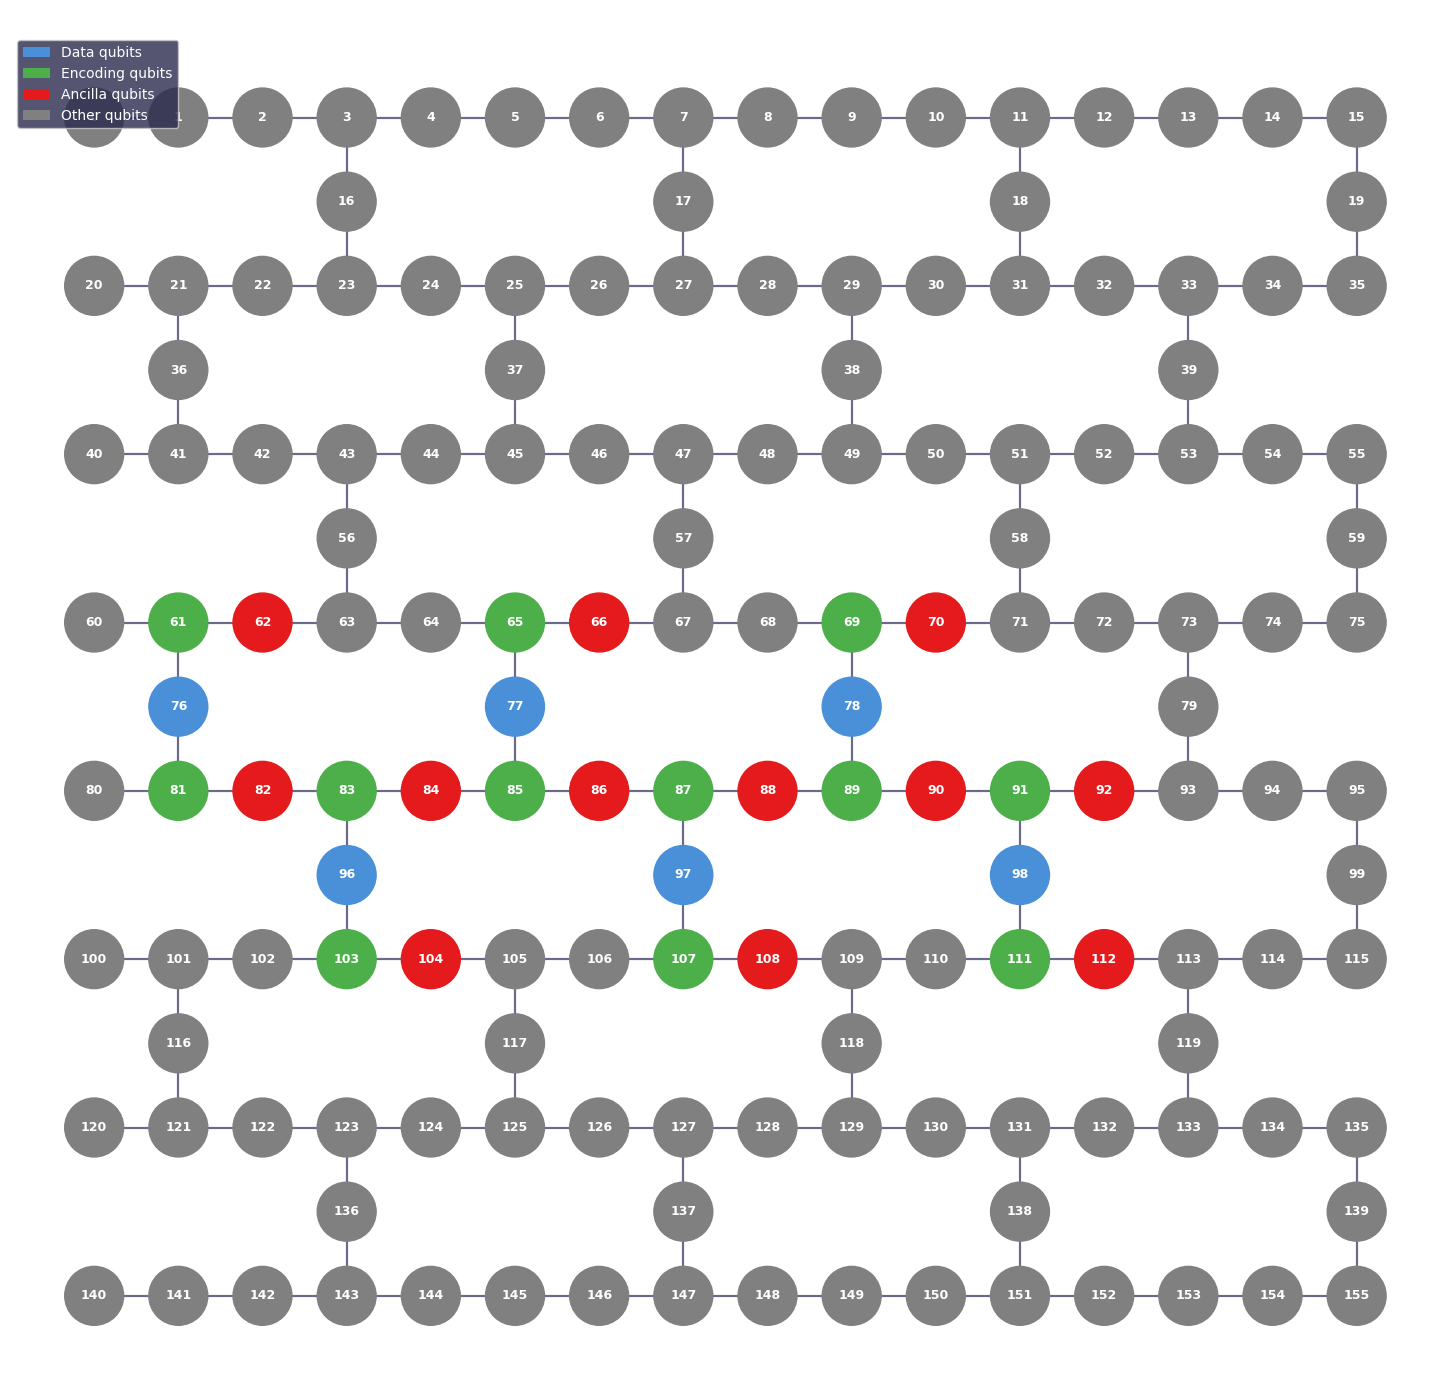

In [3]:
# ============================================================
# 1. VISUALIZE FULL FEZ TOPOLOGY WITH NODES HIGHLIGHTED
# ============================================================

# Build a rustworkx graph from the coupling map
G = rx.PyGraph()
G.add_nodes_from(range(backend.num_qubits))

for edge in coupling_map.get_edges():
    G.add_edge(edge[0], edge[1], None)

# Create IBM Fez grid positions based on the heavy-hex layout
# Position connector qubits directly below their upper-row connections for straight vertical lines
fez_positions = {}

# Row y-coordinates (inverted so 0 is at top like IBM diagram)
main_row_y = [0, -2, -4, -6, -8, -10, -12, -14]  # Main rows
conn_row_y = [-1, -3, -5, -7, -9, -11, -13]       # Connector rows (between main rows)

# Main rows: 16 qubits each
# Row 0: 0-15, Row 1: 20-35, Row 2: 40-55, Row 3: 60-75, 
# Row 4: 80-95, Row 5: 100-115, Row 6: 120-135, Row 7: 140-155
main_row_bases = [0, 20, 40, 60, 80, 100, 120, 140]

for row_idx, base in enumerate(main_row_bases):
    y = main_row_y[row_idx]
    for i in range(16):
        q = base + i
        if q < 156:
            fez_positions[q] = (i, y)

# Connector qubits - position them directly below the qubit they connect to in the row above
# Connector rows: 16-19, 36-39, 56-59, 76-79, 96-99, 116-119, 136-139
# Each connector connects vertically between two main rows

# Find the x-position for each connector based on its actual connections
connector_bases = [16, 36, 56, 76, 96, 116, 136]

for conn_idx, base in enumerate(connector_bases):
    y = conn_row_y[conn_idx]
    upper_row_base = main_row_bases[conn_idx]
    
    for i in range(4):
        q = base + i
        if q >= 156:
            continue
            
        # Find which qubit in the upper row this connector connects to
        connected_x = None
        for edge in coupling_map.get_edges():
            if edge[0] == q or edge[1] == q:
                other = edge[1] if edge[0] == q else edge[0]
                # Check if the other qubit is in the upper main row
                if upper_row_base <= other < upper_row_base + 16:
                    connected_x = other - upper_row_base
                    break
        
        if connected_x is not None:
            fez_positions[q] = (connected_x, y)
        else:
            # Fallback: use pattern-based positioning
            fez_positions[q] = (3 + i * 4, y)

# Define colors for different qubit types
COLOR_DEFAULT = 'gray'       # Default qubits
COLOR_DATA = '#4a90d9'       # Blue for data qubits
COLOR_ENCODING = '#4daf4a'   # Green for encoding qubits
COLOR_ANCILLA = '#e41a1c'    # Red for ancilla qubits

# Create color map for all qubits
node_colors = [COLOR_DEFAULT] * backend.num_qubits

# Assign colors based on qubit type in nodes
for node_id, node_data in nodes.items():
    for q in node_data["data"]:
        node_colors[q] = COLOR_DATA
    for q in node_data["encoding"]:
        node_colors[q] = COLOR_ENCODING
    for q in node_data["ancilla"]:
        node_colors[q] = COLOR_ANCILLA

# Plot
fig, ax = plt.subplots(figsize=(18, 14))
ax.set_facecolor('#1a1a2e')

# Draw edges first
for edge in coupling_map.get_edges():
    q1, q2 = edge
    if q1 in fez_positions and q2 in fez_positions:
        x1, y1 = fez_positions[q1]
        x2, y2 = fez_positions[q2]
        ax.plot([x1, x2], [y1, y2], color='#6a6a8a', linewidth=1.5, zorder=1)

# Draw nodes
for q in range(backend.num_qubits):
    if q in fez_positions:
        x, y = fez_positions[q]
        circle = plt.Circle((x, y), 0.35, color=node_colors[q], zorder=2)
        ax.add_patch(circle)
        # Add qubit number label
        ax.text(x, y, str(q), ha='center', va='center', fontsize=9, 
                color='white', fontweight='bold', zorder=3)

# Add legend
legend_elements = [
    Patch(facecolor=COLOR_DATA, label='Data qubits'),
    Patch(facecolor=COLOR_ENCODING, label='Encoding qubits'),
    Patch(facecolor=COLOR_ANCILLA, label='Ancilla qubits'),
    Patch(facecolor=COLOR_DEFAULT, label='Other qubits')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, facecolor='#2a2a4e', labelcolor='white')

ax.set_xlim(-1, 16)
ax.set_ylim(-15, 1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('IBM Fez Topology (156 qubits) with Network Nodes Highlighted', fontsize=14, color='white')
plt.tight_layout()
plt.show()

Data qubits: [76, 77, 78, 96, 97, 98]
Encoding qubits: [61, 65, 69, 81, 83, 85, 87, 89, 91, 103, 107, 111]
Ancilla qubits: [62, 66, 70, 82, 84, 86, 88, 90, 92, 104, 108, 112]
Neighbor qubits: [60, 63, 64, 67, 68, 71, 80, 93, 102, 105, 106, 109, 110, 113]
Total qubits in subgraph: 44


/var/folders/t2/g8j2h9dd5gj5c2454fz6jz980000gn/T/ipykernel_70552/3282184164.py:67: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((x, y), 0.35, color=sub_colors[q], zorder=2, edgecolor='white', linewidth=1)


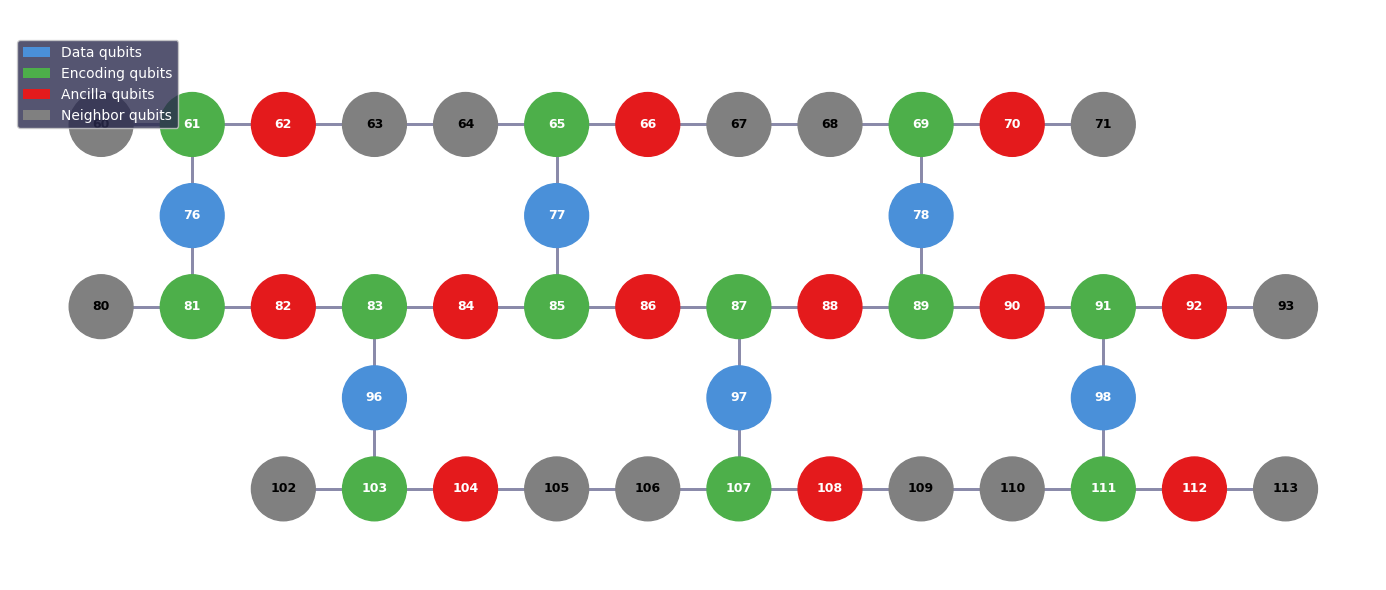

In [4]:
# ============================================================
# 2. SUBGRAPH: NODES AND THEIR IMMEDIATE NEIGHBORS
# ============================================================

# Collect all qubits in our nodes by type
data_qubits = set()
encoding_qubits = set()
ancilla_qubits = set()

for node_data in nodes.values():
    data_qubits.update(node_data["data"])
    encoding_qubits.update(node_data["encoding"])
    ancilla_qubits.update(node_data["ancilla"])

node_qubits = data_qubits | encoding_qubits | ancilla_qubits
all_node_qubits = node_qubits  # Alias for use in visualization cells

# Find all immediate neighbors of our node qubits
neighbors = set()
for q in node_qubits:
    for edge in coupling_map.get_edges():
        if edge[0] == q:
            neighbors.add(edge[1])
        elif edge[1] == q:
            neighbors.add(edge[0])

# All qubits to include in subgraph
all_relevant_qubits = node_qubits | neighbors
print(f"Data qubits: {sorted(data_qubits)}")
print(f"Encoding qubits: {sorted(encoding_qubits)}")
print(f"Ancilla qubits: {sorted(ancilla_qubits)}")
print(f"Neighbor qubits: {sorted(neighbors - node_qubits)}")
print(f"Total qubits in subgraph: {len(all_relevant_qubits)}")

# Use the fez_positions from the previous cell for consistent layout
sub_positions = {q: fez_positions[q] for q in all_relevant_qubits if q in fez_positions}

# Determine color for each qubit based on type
sub_colors = {}
for q in all_relevant_qubits:
    if q in data_qubits:
        sub_colors[q] = COLOR_DATA
    elif q in encoding_qubits:
        sub_colors[q] = COLOR_ENCODING
    elif q in ancilla_qubits:
        sub_colors[q] = COLOR_ANCILLA
    else:
        sub_colors[q] = COLOR_DEFAULT

# Plot subgraph with grid layout
fig, ax = plt.subplots(figsize=(18, 6))
ax.set_facecolor('#1a1a2e')

# Draw edges
for edge in coupling_map.get_edges():
    q1, q2 = edge
    if q1 in all_relevant_qubits and q2 in all_relevant_qubits:
        if q1 in sub_positions and q2 in sub_positions:
            x1, y1 = sub_positions[q1]
            x2, y2 = sub_positions[q2]
            ax.plot([x1, x2], [y1, y2], color='#8a8aaa', linewidth=2, zorder=1)

# Draw nodes
for q in all_relevant_qubits:
    if q in sub_positions:
        x, y = sub_positions[q]
        circle = plt.Circle((x, y), 0.35, color=sub_colors[q], zorder=2, edgecolor='white', linewidth=1)
        ax.add_patch(circle)
        # Add qubit number label
        text_color = 'white' if sub_colors[q] != COLOR_DEFAULT else 'black'
        ax.text(x, y, str(q), ha='center', va='center', fontsize=9, 
                color=text_color, fontweight='bold', zorder=3)

# Add legend
legend_elements = [
    Patch(facecolor=COLOR_DATA, label='Data qubits'),
    Patch(facecolor=COLOR_ENCODING, label='Encoding qubits'),
    Patch(facecolor=COLOR_ANCILLA, label='Ancilla qubits'),
    Patch(facecolor=COLOR_DEFAULT, label='Neighbor qubits')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, facecolor='#2a2a4e', labelcolor='white')

# Set axis limits based on subgraph positions
x_coords = [pos[0] for pos in sub_positions.values()]
y_coords = [pos[1] for pos in sub_positions.values()]
ax.set_xlim(min(x_coords) - 1, max(x_coords) + 1)
ax.set_ylim(min(y_coords) - 1, max(y_coords) + 1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Subgraph: Network Nodes and Their Immediate Neighbors (IBM Grid Layout)', fontsize=14, color='white')
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# 3. EXPLORE INTER-NODE CONNECTIONS
# ============================================================

# Find all possible paths between nodes through the coupling map
# We'll identify which nodes can potentially connect to which

print("Exploring potential inter-node connections:\n")
print("=" * 70)

# For each pair of nodes, find if there's a path and what the shortest path is
from itertools import combinations

# Build a graph for pathfinding
path_graph = rx.PyGraph()
path_graph.add_nodes_from(range(backend.num_qubits))
for edge in coupling_map.get_edges():
    path_graph.add_edge(edge[0], edge[1], 1)  # weight = 1

# Helper function to get all qubits from a node
def get_all_qubits(node_dict):
    """Extract all qubit indices from a node definition"""
    all_q = []
    for q_list in node_dict.values():
        all_q.extend(q_list)
    return all_q

# Check direct connections between node clusters
print("\nDirect connections (edges) between different node clusters:")
print("-" * 70)

inter_node_edges = []
for (node_a, qubits_dict_a), (node_b, qubits_dict_b) in combinations(nodes.items(), 2):
    qubits_a = get_all_qubits(qubits_dict_a)
    qubits_b = get_all_qubits(qubits_dict_b)
    for qa in qubits_a:
        for qb in qubits_b:
            if (qa, qb) in edges or (qb, qa) in edges:
                inter_node_edges.append((node_a, node_b, qa, qb))
                print(f"  Node {node_a} <-> Node {node_b}: qubit {qa} -- qubit {qb}")

if not inter_node_edges:
    print("  No direct edges between node clusters")

# Find shortest paths between all node pairs
print("\n\nShortest paths between node clusters:")
print("-" * 70)

shortest_paths = {}
for (node_a, qubits_dict_a), (node_b, qubits_dict_b) in combinations(nodes.items(), 2):
    qubits_a = get_all_qubits(qubits_dict_a)
    qubits_b = get_all_qubits(qubits_dict_b)
    
    min_path_len = float('inf')
    best_path = None
    best_qa, best_qb = None, None
    
    for qa in qubits_a:
        for qb in qubits_b:
            try:
                # Find shortest path
                path = rx.dijkstra_shortest_paths(path_graph, qa, qb, weight_fn=lambda x: 1)
                if qb in path:
                    path_list = path[qb]
                    if len(path_list) < min_path_len:
                        min_path_len = len(path_list)
                        best_path = path_list
                        best_qa, best_qb = qa, qb
            except:
                pass
    
    if best_path is not None:
        shortest_paths[(node_a, node_b)] = {
            'length': min_path_len - 1,  # edges = nodes - 1
            'path': best_path,
            'from_qubit': best_qa,
            'to_qubit': best_qb
        }
        print(f"  Node {node_a} -> Node {node_b}: {min_path_len - 1} hops")
        print(f"    Path: {' -> '.join(map(str, best_path))}")

# Create a summary adjacency matrix for inter-node distances
print("\n\nInter-node distance matrix (number of hops):")
print("-" * 70)

# Print header
print("      ", end="")
for i in range(6):
    print(f"Node {i}  ", end="")
print()

for i in range(6):
    print(f"Node {i}", end="  ")
    for j in range(6):
        if i == j:
            print("  -   ", end="  ")
        elif i < j:
            key = (i, j)
            if key in shortest_paths:
                print(f"  {shortest_paths[key]['length']}   ", end="  ")
            else:
                print("  ∞   ", end="  ")
        else:
            key = (j, i)
            if key in shortest_paths:
                print(f"  {shortest_paths[key]['length']}   ", end="  ")
            else:
                print("  ∞   ", end="  ")
    print()

Exploring potential inter-node connections:


Direct connections (edges) between different node clusters:
----------------------------------------------------------------------
  Node 0 <-> Node 3: qubit 82 -- qubit 83
  Node 1 <-> Node 3: qubit 85 -- qubit 84
  Node 1 <-> Node 4: qubit 86 -- qubit 87
  Node 2 <-> Node 4: qubit 89 -- qubit 88
  Node 2 <-> Node 5: qubit 90 -- qubit 91


Shortest paths between node clusters:
----------------------------------------------------------------------
  Node 0 -> Node 1: 3 hops
    Path: 62 -> 63 -> 64 -> 65
  Node 0 -> Node 2: 7 hops
    Path: 62 -> 63 -> 64 -> 65 -> 66 -> 67 -> 68 -> 69
  Node 0 -> Node 3: 1 hops
    Path: 82 -> 83
  Node 0 -> Node 4: 5 hops
    Path: 82 -> 83 -> 84 -> 85 -> 86 -> 87
  Node 0 -> Node 5: 9 hops
    Path: 82 -> 83 -> 84 -> 85 -> 86 -> 87 -> 88 -> 89 -> 90 -> 91
  Node 1 -> Node 2: 3 hops
    Path: 66 -> 67 -> 68 -> 69
  Node 1 -> Node 3: 1 hops
    Path: 85 -> 84
  Node 1 -> Node 4: 1 hops
    Path: 86 -> 87
  

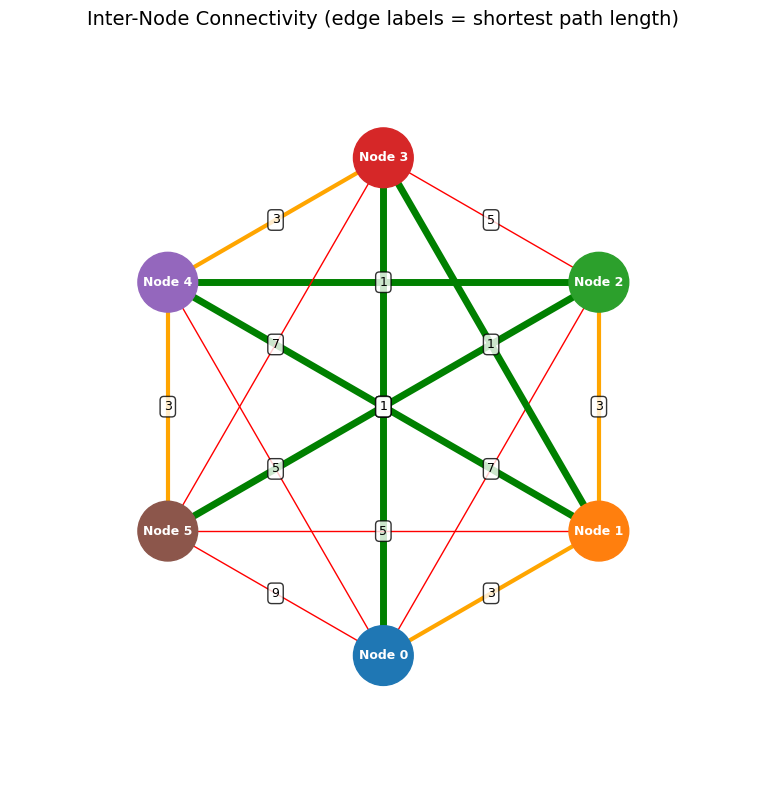


Legend: Green = 1-2 hops, Orange = 3-4 hops, Red = 5+ hops


In [6]:
# ============================================================
# VISUALIZE INTER-NODE CONNECTIVITY GRAPH
# ============================================================

import math

fig, ax = plt.subplots(figsize=(10, 8))

# Position nodes in a circle
pos = {}
for i in range(6):
    angle = 2 * math.pi * i / 6 - math.pi / 2  # Start from top
    pos[i] = (math.cos(angle), math.sin(angle))

# Define node colors for the 6 nodes
node_colors_graph = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Draw edges first (so they appear behind nodes)
for (node_a, node_b), info in shortest_paths.items():
    x1, y1 = pos[node_a]
    x2, y2 = pos[node_b]
    
    weight = info['length']
    # Thicker lines for shorter paths
    line_width = max(1, 6 - weight)
    # Color based on distance
    if weight <= 2:
        edge_color = 'green'
    elif weight <= 4:
        edge_color = 'orange'
    else:
        edge_color = 'red'
    
    ax.plot([x1, x2], [y1, y2], color=edge_color, linewidth=line_width, zorder=1)
    
    # Add edge label at midpoint
    mid_x = (x1 + x2) / 2
    mid_y = (y1 + y2) / 2
    ax.annotate(f'{weight}', (mid_x, mid_y), fontsize=9, ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), zorder=3)

# Draw nodes
for i in range(6):
    x, y = pos[i]
    circle = plt.Circle((x, y), 0.12, color=node_colors_graph[i], zorder=2)
    ax.add_patch(circle)
    ax.text(x, y, f"Node {i}", ha='center', va='center', fontsize=9, 
            color='white', fontweight='bold', zorder=4)

ax.set_title('Inter-Node Connectivity (edge labels = shortest path length)', fontsize=14)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

print("\nLegend: Green = 1-2 hops, Orange = 3-4 hops, Red = 5+ hops")

In [7]:
# ============================================================
# TRANSPORT ROUTES: Hardcoded paths for "train-like" qubit transport
# ============================================================
# 
# Structure:
#   - Each route is keyed by (source_node, dest_node)
#   - "movements" is a list of lists (paths), ordered by execution sequence
#   - The first list is the first qubit to start swapping, etc.
#
# TRAIN MODEL:
#   - All 3 qubits travel the SAME number of SWAPs (equal path lengths)
#   - Each qubit ends at its CORRESPONDING position in the destination node
#   - Order: [leading qubit, middle qubit, trailing qubit]
# ============================================================

transport_routes = {
    # ========== NODE 0 ==========
    # Node 0 --> Node 1 (horizontal)
    (0, 1): {
        "description": "Node 0 --> Node 1 (rightward)",
        "movements": [
            [61, 62, 63, 64, 65, 77, 85],  # encoding_0 → dest encoding_1
            [76, 61, 62, 63, 64, 65, 77],  # data → dest data
            [81, 76, 61, 62, 63, 64, 65],  # encoding_1 → dest encoding_0
        ]
    },
    # Node 0 --> Node 2 (horizontal + horizontal)
    (0, 2): {
        "description": "Node 0 --> Node 2 (rightward, then rightward)",
        "movements": [
            [61, 62, 63, 64, 65, 66, 67, 68, 69, 78, 89], # encoding_0 → dest encoding_1
            [76, 61, 62, 63, 64, 65, 66, 67, 68, 69, 78], # data → dest data
            [81, 76, 61, 62, 63, 64, 65, 66, 67, 68, 69],  # encoding_1 → dest encoding_0
        ]
    },
    # Node 0 --> Node 3 (vertical)
    (0, 3): {
        "description": "Node 0 --> Node 3 (downward)",
        "movements": [
            [81, 82, 83, 96, 103],  # encoding_1 → dest encoding_1
            [76, 81, 82, 83, 96],   # data → dest data
            [61, 76, 81, 82, 83],   # encoding_0 → dest encoding_0
        ]
    },
    # Node 0 --> Node 4 (horizontal + vertical)
    (0, 4): {
        "description": "Node 0 --> Node 4 (rightward, then downward)",
        "movements": [
            [81, 82, 83, 84, 85, 86, 87, 97, 107],  # encoding_1 → dest encoding_1
            [76, 81, 82, 83, 84, 85, 86, 87, 97],   # data → dest data
            [61, 76, 81, 82, 83, 84, 85, 86, 87],   # encoding_0 → dest encoding_0
        ]
    },
    # Node 0 --> Node 5 (horizontal + horizontal + vertical)
    (0, 5): {
        "description": "Node 0 --> Node 5 (rightward, rightward, then downward)",
        "movements": [
            [81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 98, 111],  # encoding_1 → dest encoding_1
            [76, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 98],   # data → dest data
            [61, 76, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91],   # encoding_0 → dest encoding_0
        ]
    },

    # ========== NODE 1 ==========
    # Node 1 --> Node 0 (horizontal)
    (1, 0): {
        "description": "Node 1 --> Node 0 (leftward)",
        "movements": [
            [65, 64, 63, 62, 61, 76, 81],  # encoding_0 → dest encoding_1
            [77, 65, 64, 63, 62, 61, 76],  # data → dest data
            [85, 77, 65, 64, 63, 62, 61],  # encoding_1 → dest encoding_0
        ]
    },
    # Node 1 --> Node 2 (horizontal)
    (1, 2): {
        "description": "Node 1 --> Node 2 (rightward)",
        "movements": [
            [65, 66, 67, 68, 69, 78, 89], # encoding_0 → dest encoding_1
            [77, 65, 66, 67, 68, 69, 78],  # data → dest data
            [85, 77, 65, 66, 67, 68, 69],  # encoding_1 → dest encoding_0
        ]
    },
    # Node 1 --> Node 3 (horizontal + vertical)
    (1, 3): {
        "description": "Node 1 --> Node 3 (leftward, then downward)",
        "movements": [
            [85, 84, 83, 96, 103],  # encoding_1 → dest encoding_1
            [77, 85, 84, 83, 96],   # data → dest data
            [65, 77, 85, 84, 83],   # encoding_0 → dest encoding_0
        ]
    },
    # Node 1 --> Node 4 (vertical)
    (1, 4): {
        "description": "Node 1 --> Node 4 (downward)",
        "movements": [
            [85, 86, 87, 97, 107],  # encoding_1 → dest encoding_1
            [77, 85, 86, 87, 97],   # data → dest data
            [65, 77, 85, 86, 87],   # encoding_0 → dest encoding_0
        ]
    },
    # Node 1 --> Node 5 (horizontal + vertical)
    (1, 5): {
        "description": "Node 1 --> Node 5 (rightward, then downward)",
        "movements": [
            [85, 86, 87, 88, 89, 90, 91, 98, 111],  # encoding_1 → dest encoding_1
            [77, 85, 86, 87, 88, 89, 90, 91, 98],   # data → dest data
            [65, 77, 85, 86, 87, 88, 89, 90, 91],   # encoding_0 → dest encoding_0
        ]
    },

    # ========== NODE 2 ==========
    # Node 2 --> Node 0 (horizontal + horizontal)
    (2, 0): {
        "description": "Node 2 --> Node 0 (leftward, then leftward)",
        "movements": [
            [69, 68, 67, 66, 65, 64, 63, 62, 61, 76, 81], # encoding_0 → dest encoding_1
            [78, 69, 68, 67, 66, 65, 64, 63, 62, 61, 76], # data → dest data
            [89, 78, 69, 68, 67, 66, 65, 64, 63, 62, 61], # encoding_1 → dest encoding_0
        ]
    },
    # Node 2 --> Node 1 (horizontal)
    (2, 1): {
        "description": "Node 2 --> Node 1 (leftward)",
        "movements": [
            [69, 68, 67, 66, 65, 77, 85],  # encoding_0 → dest encoding_1
            [78, 69, 68, 67, 66, 65, 77],  # data → dest data
            [89, 78, 69, 68, 67, 66, 65],  # encoding_1 → dest encoding_0
        ]
    },
    # Node 2 --> Node 3 (horizontal + vertical)
    (2, 3): {
        "description": "Node 2 --> Node 3 (leftward, leftward, then downward)",
        "movements": [
            [89, 88, 87, 86, 85, 84, 83, 96, 103],  # encoding_1 → dest encoding_1
            [78, 89, 88, 87, 86, 85, 84, 83, 96],   # data → dest data
            [69, 78, 89, 88, 87, 86, 85, 84, 83],   # encoding_0 → dest encoding_0
        ]
    },
    # Node 2 --> Node 4 (horizontal + vertical)
    (2, 4): {
        "description": "Node 2 --> Node 4 (leftward, then downward)",
        "movements": [
            [89, 88, 87, 97, 107],  # encoding_1 → dest encoding_1
            [78, 89, 88, 87, 97],   # data → dest data
            [69, 78, 89, 88, 87],   # encoding_0 → dest encoding_0
        ]
    },
    # Node 2 --> Node 5 (vertical)
    (2, 5): {
        "description": "Node 2 --> Node 5 (downward)",
        "movements": [
            [89, 90, 91, 98, 111],  # encoding_1 → dest encoding_1
            [78, 89, 90, 91, 98],   # data → dest data
            [69, 78, 89, 90, 91],   # encoding_0 → dest encoding_0
        ]
    },
    
    # ========== NODE 3 ==========
    # Node 3 --> Node 0 (vertical)    
    (3, 0): {
        "description": "Node 3 → Node 0 (upward)",
        "movements": [
            [83, 82, 81, 76, 61],   # encoding_0 → dest encoding_0
            [96, 83, 82, 81, 76],   # data → dest data
            [103, 96, 83, 82, 81],  # encoding_1 → dest encoding_1
        ]
    },
    # Node 3 --> Node 1 (horizontal + vertical)
    (3, 1): {
        "description": "Node 3 --> Node 1 (upward, then leftward)",
        "movements": [
            [83, 84, 85, 77, 65],   # encoding_0 → dest encoding_0
            [96, 83, 84, 85, 77],   # data → dest data
            [103, 96, 83, 84, 85],  # encoding_1 → dest encoding_1
        ]
    },
    # Node 3 --> Node 2 (horizontal + horizontal + vertical)
    (3, 2): {
        "description": "Node 3 --> Node 2 (upward, leftward, then leftward)",
        "movements": [
            [83, 84, 85, 86, 87, 88, 89, 78, 69],   # encoding_0 → dest encoding_0
            [96, 83, 84, 85, 86, 87, 88, 89, 78],   # data → dest data
            [103, 96, 83, 84, 85, 86, 87, 88, 89],  # encoding_1 → dest encoding_1
        ]
    },
    # Node 3 --> Node 4 (horizontal)
    (3, 4): {
        "description": "Node 3 --> Node 4 (rightward)",
        "movements": [
            [103, 104, 105, 106, 107, 97, 87],  # encoding_1 → dest encoding_0
            [96, 103, 104, 105, 106, 107, 97],  # data → dest data
            [83, 96, 103, 104, 105, 106, 107],  # encoding_0 → dest encoding_1
        ]
    },
    # Node 3 --> Node 5 (horizontal + horizontal)
    (3, 5): {
        "description": "Node 3 --> Node 5 (rightward, then rightward)",
        "movements": [
            [103, 104, 105, 106, 107, 108, 109, 110, 111, 98, 91],  # encoding_1 → dest encoding_0
            [96, 103, 104, 105, 106, 107, 108, 109, 110, 111, 98],  # data → dest data
            [83, 96, 103, 104, 105, 106, 107, 108, 109, 110, 111],  # encoding_0 → dest encoding_1
        ]
    },

    # ========== NODE 4 ==========
    # Node 4 --> Node 0 (vertical + horizontal)    
    (4, 0): {
        "description": "Node 4 --> Node 0 (upward, then leftward)",
        "movements": [
            [87, 86, 85, 84, 83, 82, 81, 76, 61],   # encoding_0 → dest encoding_0
            [97, 87, 86, 85, 84, 83, 82, 81, 76],   # data → dest data
            [107, 97, 87, 86, 85, 84, 83, 82, 81],  # encoding_1 → dest encoding_1
        ]
    },
    # Node 4 --> Node 1 (vertical)
    (4, 1): {
        "description": "Node 4 --> Node 1 (upward)",
        "movements": [
            [87, 86, 85, 77, 65],   # encoding_0 → dest encoding_0
            [97, 87, 86, 85, 77],   # data → dest data
            [107, 97, 87, 86, 85],  # encoding_1 → dest encoding_1
        ]
    },
    # Node 4 --> Node 2 (vertical + horizontal)
    (4, 2): {
        "description": "Node 4 --> Node 2 (upward, then rightward)",
        "movements": [
            [87, 88, 89, 78, 69],   # encoding_0 → dest encoding_0
            [97, 87, 88, 89, 78],   # data → dest data
            [107, 97, 87, 88, 89],  # encoding_1 → dest encoding_1
        ]
    },
    # Node 4 --> Node 3 (horizontal)
    (4, 3): {
        "description": "Node 4 --> Node 3 (leftward)",
        "movements": [
            [107, 106, 105, 104, 103, 96, 83],  # encoding_1 → dest encoding_0
            [97, 107, 106, 105, 104, 103, 96],  # data → dest data
            [87, 97, 107, 106, 105, 104, 103],   # encoding_0 → dest encoding_1
        ]
    },
    # Node 4 --> Node 5 (horizontal)
    (4, 5): {
        "description": "Node 4 --> Node 5 (rightward)",
        "movements": [
            [107, 108, 109, 110, 111, 98, 91],  # encoding_1 → dest encoding_0
            [97, 107, 108, 109, 110, 111, 98],  # data → dest data
            [87, 97, 107, 108, 109, 110, 111],  # encoding_0 → dest encoding_1
        ]
    },
    # ========== NODE 5 ==========
    # Node 5 --> Node 0 (vertical + horizontal + horizontal)    
    (5, 0): {
        "description": "Node 5 → Node 0 (upward, then leftward, then leftward)",
        "movements": [
            [91, 90, 89, 88, 87, 86, 85, 84, 83, 82, 81, 76, 61],   # encoding_0 → dest encoding_0
            [98, 91, 90, 89, 88, 87, 86, 85, 84, 83, 82, 81, 76],   # data → dest data
            [111, 98, 91, 90, 89, 88, 87, 86, 85, 84, 83, 82, 81],  # encoding_1 → dest encoding_1
        ]
    },
    # Node 5 --> Node 1 (vertical + horizontal)
    (5, 1): {
        "description": "Node 5 → Node 1 (upward, then leftward)",
        "movements": [
            [91, 90, 89, 88, 87, 86, 85, 77, 65],   # encoding_0 → dest encoding_0
            [98, 91, 90, 89, 88, 87, 86, 85, 77],   # data → dest data
            [111, 98, 91, 90, 89, 88, 87, 86, 85],  # encoding_1 → dest encoding_1
        ]
    },
    # Node 5 --> Node 2 (vertical)
    (5, 2): {
        "description": "Node 5 → Node 2 (upward)",
        "movements": [
            [91, 90, 89, 78, 69],   # encoding_0 → dest encoding_0
            [98, 91, 90, 89, 78],   # data → dest data
            [111, 98, 91, 90, 89],  # encoding_1 → dest encoding_1
        ]
    },
    # Node 5 --> Node 3 (horizontal + vertical)
    (5, 3): {
        "description": "Node 5 → Node 3 (leftward, then upward)",
        "movements": [
            [111, 110, 109, 108, 107, 106, 105, 104, 103, 96, 83],  # encoding_1 → dest encoding_0
            [98, 111, 110, 109, 108, 107, 106, 105, 104, 103, 96],  # data → dest data
            [91, 98, 111, 110, 109, 108, 107, 106, 105, 104, 103], # encoding_0 → dest encoding_1
        ] 
    },
    # Node 5 --> Node 4 (horizontal)
    (5, 4): {
        "description": "Node 5 → Node 4 (leftward)",
        "movements": [
            [111, 110, 109, 108, 107, 97, 87], # encoding_1 → dest encoding_0
            [98, 111, 110, 109, 108, 107, 97], # data → dest data
            [91, 98, 111, 110, 109, 108, 107], # encoding_0 → dest encoding_1
        ]
    },
}

# Print summary with path length verification
print(f" {len(transport_routes)} Transport Routes Summary (with path length verification):")
print("=" * 70)
for (src, dst), route in transport_routes.items():
    print(f"\n{route['description']}:")
    lengths = []
    for i, path in enumerate(route['movements']):
        path_len = len(path) - 1  # number of SWAPs
        lengths.append(path_len)
        path_str = " → ".join(map(str, path))
        print(f"  Path {i+1}: {path_str} ({path_len} SWAPs)")
    
    if len(set(lengths)) == 1:
        print(f"  ✓ All paths equal length: {lengths[0]} SWAPs")
    else:
        print(f"  ✗ UNEQUAL path lengths: {lengths}")

 30 Transport Routes Summary (with path length verification):

Node 0 --> Node 1 (rightward):
  Path 1: 61 → 62 → 63 → 64 → 65 → 77 → 85 (6 SWAPs)
  Path 2: 76 → 61 → 62 → 63 → 64 → 65 → 77 (6 SWAPs)
  Path 3: 81 → 76 → 61 → 62 → 63 → 64 → 65 (6 SWAPs)
  ✓ All paths equal length: 6 SWAPs

Node 0 --> Node 2 (rightward, then rightward):
  Path 1: 61 → 62 → 63 → 64 → 65 → 66 → 67 → 68 → 69 → 78 → 89 (10 SWAPs)
  Path 2: 76 → 61 → 62 → 63 → 64 → 65 → 66 → 67 → 68 → 69 → 78 (10 SWAPs)
  Path 3: 81 → 76 → 61 → 62 → 63 → 64 → 65 → 66 → 67 → 68 → 69 (10 SWAPs)
  ✓ All paths equal length: 10 SWAPs

Node 0 --> Node 3 (downward):
  Path 1: 81 → 82 → 83 → 96 → 103 (4 SWAPs)
  Path 2: 76 → 81 → 82 → 83 → 96 (4 SWAPs)
  Path 3: 61 → 76 → 81 → 82 → 83 (4 SWAPs)
  ✓ All paths equal length: 4 SWAPs

Node 0 --> Node 4 (rightward, then downward):
  Path 1: 81 → 82 → 83 → 84 → 85 → 86 → 87 → 97 → 107 (8 SWAPs)
  Path 2: 76 → 81 → 82 → 83 → 84 → 85 → 86 → 87 → 97 (8 SWAPs)
  Path 3: 61 → 76 → 81 → 82 → 83 

In [8]:
# ============================================================
# VALIDATION: Verify all transport paths use valid edges AND no collisions
# ============================================================
# 
# Checks:
#   1. Edge validation: Each step uses a valid coupling map edge
#   2. Endpoint validation: Start/end positions are data/encoding qubits of src/dst nodes
#   3. Collision detection: No two "used" qubits collide during transport
# ============================================================

# Build set of valid edges (bidirectional)
valid_edges = set()
for q1, q2 in coupling_map:
    valid_edges.add((q1, q2))
    valid_edges.add((q2, q1))

# Helper to get data + encoding qubits for a node
def get_data_encoding_qubits(node_id):
    """Get set of data and encoding qubits for a node (not ancilla)"""
    return set(nodes[node_id]['data'] + nodes[node_id]['encoding'])

print("Transport Route Validation (Edges + Endpoints + Collisions)")
print("=" * 70)

all_valid = True
all_collision_free = True
all_endpoints_valid = True

for (src, dst), route in transport_routes.items():
    route_valid = True
    collision_free = True
    endpoints_valid = True
    invalid_steps = []
    collision_steps = []
    endpoint_errors = []
    
    # Get valid start/end qubits
    src_qubits = get_data_encoding_qubits(src)
    dst_qubits = get_data_encoding_qubits(dst)
    
    # --- EDGE VALIDATION ---
    for idx, path in enumerate(route['movements']):
        for i in range(len(path) - 1):
            edge = (path[i], path[i+1])
            if edge not in valid_edges:
                route_valid = False
                invalid_steps.append(f"Path {idx+1}: {path[i]}→{path[i+1]}")
    
    # --- ENDPOINT VALIDATION ---
    for idx, path in enumerate(route['movements']):
        start_pos = path[0]
        end_pos = path[-1]
        
        if start_pos not in src_qubits:
            endpoints_valid = False
            endpoint_errors.append(
                f"Path {idx+1}: Start {start_pos} not in Node {src} data/encoding {sorted(src_qubits)}"
            )
        if end_pos not in dst_qubits:
            endpoints_valid = False
            endpoint_errors.append(
                f"Path {idx+1}: End {end_pos} not in Node {dst} data/encoding {sorted(dst_qubits)}"
            )
    
    # --- COLLISION DETECTION ---
    # Initialize "used" set with starting positions of all paths (first element of each path)
    used_positions = set()
    for path in route['movements']:
        used_positions.add(path[0])  # Starting position of each qubit
    
    # Execute each path in order
    for path_idx, path in enumerate(route['movements']):
        current_pos = path[0]
        
        # Simulate each SWAP along this path
        for step_idx in range(len(path) - 1):
            next_pos = path[step_idx + 1]
            
            # Check: is the target position already "used"?
            if next_pos in used_positions and next_pos != current_pos:
                collision_free = False
                collision_steps.append(
                    f"Path {path_idx+1}, Step {step_idx+1}: "
                    f"SWAP {current_pos}→{next_pos} collides (position {next_pos} is used)"
                )
            
            # Update used positions: qubit moves from current_pos to next_pos
            used_positions.discard(current_pos)
            used_positions.add(next_pos)
            current_pos = next_pos
    
    # --- PRINT RESULTS ---
    if route_valid and collision_free and endpoints_valid:
        print(f"✓ Route ({src}→{dst}): Valid edges, Valid endpoints, No collisions")
    else:
        print(f"Route ({src}→{dst}):")
        if not route_valid:
            print(f"  ✗ INVALID edges:")
            for step in invalid_steps:
                print(f"      - {step}")
        if not endpoints_valid:
            print(f"  ✗ INVALID endpoints:")
            for err in endpoint_errors:
                print(f"      - {err}")
        if not collision_free:
            print(f"  ✗ COLLISIONS detected:")
            for step in collision_steps:
                print(f"      - {step}")
    
    if not route_valid:
        all_valid = False
    if not collision_free:
        all_collision_free = False
    if not endpoints_valid:
        all_endpoints_valid = False

print("\n" + "=" * 70)
print("Summary:")
if all_valid:
    print("  ✓ All edges are valid")
else:
    print("  ✗ Some routes have invalid edges")
if all_endpoints_valid:
    print("  ✓ All endpoints are valid (start/end in data/encoding qubits)")
else:
    print("  ✗ Some routes have invalid endpoints")
if all_collision_free:
    print("  ✓ No collisions detected")
else:
    print("  ✗ Some routes have collisions")

if all_valid and all_collision_free and all_endpoints_valid:
    print("\n✓ ALL ROUTES VALIDATED SUCCESSFULLY")
else:
    print("\n✗ VALIDATION FAILED - REVIEW REQUIRED")

Transport Route Validation (Edges + Endpoints + Collisions)
✓ Route (0→1): Valid edges, Valid endpoints, No collisions
✓ Route (0→2): Valid edges, Valid endpoints, No collisions
✓ Route (0→3): Valid edges, Valid endpoints, No collisions
✓ Route (0→4): Valid edges, Valid endpoints, No collisions
✓ Route (0→5): Valid edges, Valid endpoints, No collisions
✓ Route (1→0): Valid edges, Valid endpoints, No collisions
✓ Route (1→2): Valid edges, Valid endpoints, No collisions
✓ Route (1→3): Valid edges, Valid endpoints, No collisions
✓ Route (1→4): Valid edges, Valid endpoints, No collisions
✓ Route (1→5): Valid edges, Valid endpoints, No collisions
✓ Route (2→0): Valid edges, Valid endpoints, No collisions
✓ Route (2→1): Valid edges, Valid endpoints, No collisions
✓ Route (2→3): Valid edges, Valid endpoints, No collisions
✓ Route (2→4): Valid edges, Valid endpoints, No collisions
✓ Route (2→5): Valid edges, Valid endpoints, No collisions
✓ Route (3→0): Valid edges, Valid endpoints, No collisi

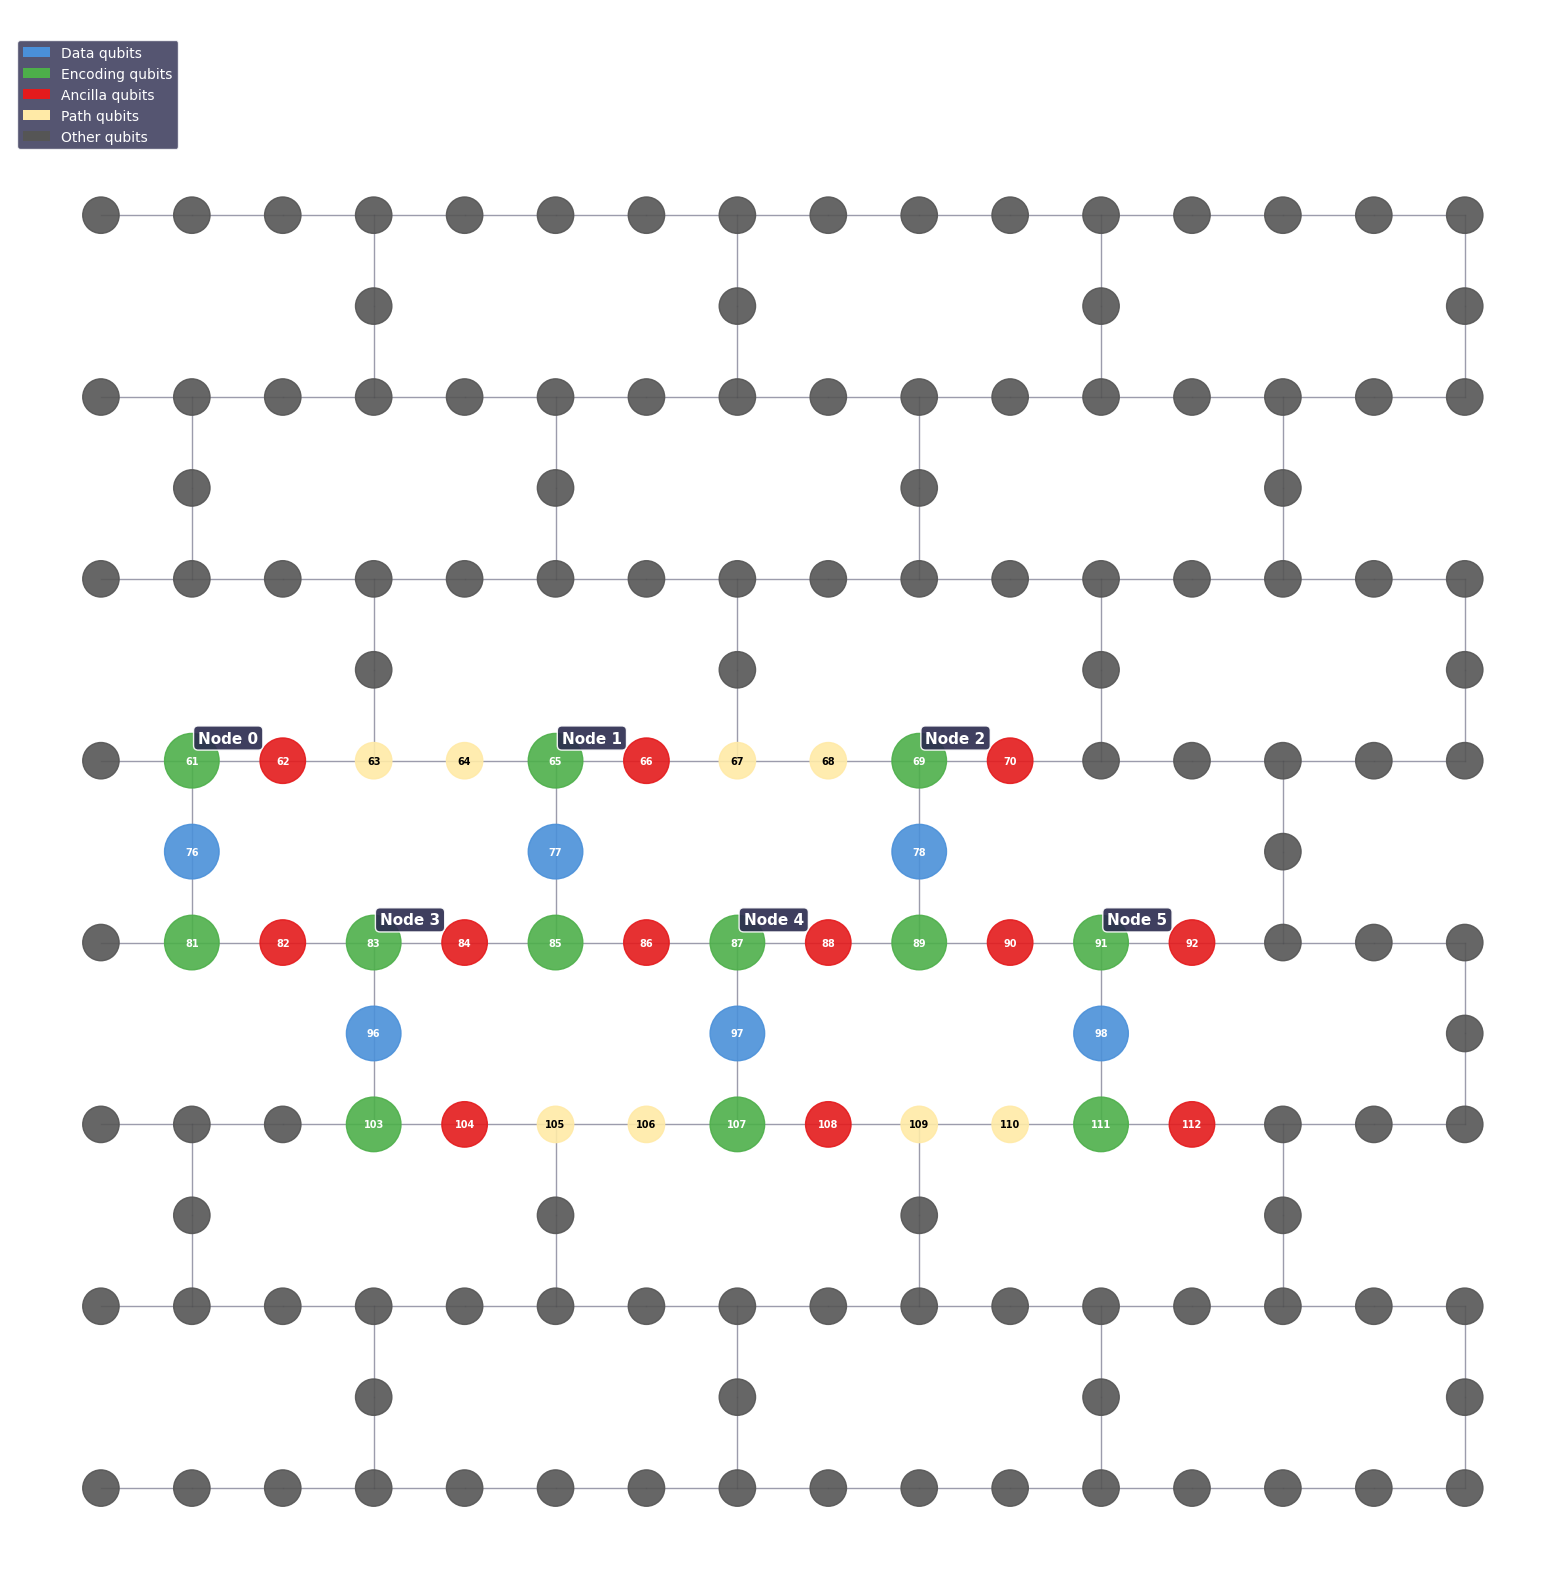


Total routes defined: 30
Total unique path qubits used: 35
Node qubits: 30


In [9]:
# ============================================================
# VISUALIZATION: ALL TRANSPORT ROUTES OVERVIEW
# ============================================================
# Shows all routes on a single topology map with color-coded paths

# Collect all path qubits from all routes
all_path_qubits = set()
for route_data in transport_routes.values():
    for path in route_data['movements']:
        all_path_qubits.update(path)

# Define a colormap for different routes
route_colors = {
    # Horizontal routes (top row)
    (0, 1): '#e74c3c',  # Red
    (1, 0): '#c0392b',  # Dark red
    (1, 2): '#3498db',  # Blue
    (2, 1): '#2980b9',  # Dark blue
    # Horizontal routes (bottom row)
    (3, 4): '#9b59b6',  # Purple
    (4, 3): '#8e44ad',  # Dark purple
    (4, 5): '#1abc9c',  # Teal
    (5, 4): '#16a085',  # Dark teal
    # Vertical routes
    (0, 3): '#e67e22',  # Orange
    (3, 0): '#d35400',  # Dark orange
    (1, 4): '#f1c40f',  # Yellow
    (4, 1): '#f39c12',  # Gold
    (2, 5): '#2ecc71',  # Green
    (5, 2): '#27ae60',  # Dark green
    # Non-adjacent routes
    (0, 2): '#ff6b6b',  # Coral
    (2, 0): '#ee5a5a',  # Dark coral
    (3, 5): '#a29bfe',  # Lavender
    (5, 3): '#6c5ce7',  # Indigo
}

fig, ax = plt.subplots(figsize=(20, 16))
ax.set_facecolor('#1a1a2e')

# Draw all coupling map edges as background
for q1, q2 in edges:
    if q1 in fez_positions and q2 in fez_positions and q1 < q2:
        x1, y1 = fez_positions[q1]
        x2, y2 = fez_positions[q2]
        ax.plot([x1, x2], [y1, y2], color='#3a3a5a', linewidth=1, zorder=1, alpha=0.5)

# Draw nodes
for q in range(backend.num_qubits):
    if q in fez_positions:
        x, y = fez_positions[q]
        
        # Determine color based on qubit type
        if q in data_qubits:
            color = COLOR_DATA
            size = 0.3
        elif q in encoding_qubits:
            color = COLOR_ENCODING
            size = 0.3
        elif q in ancilla_qubits:
            color = COLOR_ANCILLA
            size = 0.25
        elif q in all_path_qubits:
            color = '#ffeaa7'  # Light yellow for path qubits
            size = 0.2
        else:
            color = '#555555'
            size = 0.2
        
        circle = plt.Circle((x, y), size, color=color, zorder=2, alpha=0.9)
        ax.add_patch(circle)
        
        # Label important qubits
        if q in all_node_qubits or q in all_path_qubits:
            ax.text(x, y, str(q), ha='center', va='center', fontsize=7,
                    color='black' if color == '#ffeaa7' else 'white', fontweight='bold', zorder=3)

# Add node cluster labels
for node_id, node_data in nodes.items():
    all_qs = node_data['data'] + node_data['encoding'] + node_data['ancilla']
    center_x = np.mean([fez_positions[q][0] for q in all_qs])
    center_y = np.mean([fez_positions[q][1] for q in all_qs])
    ax.annotate(f"Node {node_id}", (center_x, center_y + 1.2), ha='center', fontsize=11,
                fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a2a4e', edgecolor='white', alpha=0.9))

# Legend
legend_elements = [
    Patch(facecolor=COLOR_DATA, label='Data qubits'),
    Patch(facecolor=COLOR_ENCODING, label='Encoding qubits'),
    Patch(facecolor=COLOR_ANCILLA, label='Ancilla qubits'),
    Patch(facecolor='#ffeaa7', label='Path qubits'),
    Patch(facecolor='#555555', label='Other qubits'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, 
          facecolor='#2a2a4e', labelcolor='white', edgecolor='white')

ax.set_xlim(-1, 16)
ax.set_ylim(-15, 2)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('All Transport Routes Overview - Network Nodes and Path Qubits', 
             fontsize=16, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nTotal routes defined: {len(transport_routes)}")
print(f"Total unique path qubits used: {len(all_path_qubits)}")
print(f"Node qubits: {len(all_node_qubits)}")

In [10]:
# ============================================================
# SEQUENTIAL QUBIT MOVEMENT ANALYSIS
# ============================================================
# For each route, show how each qubit moves step-by-step
# The "train model" means paths are executed sequentially: Path 1 completes, then Path 2, then Path 3

def explain_sequential_movement(route_key):
    """
    Explain the sequential movement of qubits for a given route.
    In sequential execution:
    - Path 1 (leading qubit) moves first, completing all its SWAPs
    - Path 2 (middle qubit) moves second
    - Path 3 (trailing qubit) moves last
    """
    src, dst = route_key
    route = transport_routes[route_key]
    paths = route['movements']
    
    print(f"\n{'='*70}")
    print(f"Route: {route['description']}")
    print(f"{'='*70}")
    
    # Initial state
    print(f"\n📍 INITIAL STATE (before any movement):")
    for i, path in enumerate(paths):
        qubit_type = ["encoding_1/encoding_0", "data", "encoding_0/encoding_1"][i] if len(paths) == 3 else f"qubit_{i+1}"
        print(f"   Qubit {i+1} ({qubit_type}): at position {path[0]}")
    
    # Track positions through sequential execution
    qubit_positions = {i: paths[i][0] for i in range(len(paths))}
    
    # Execute each path sequentially
    for path_idx, path in enumerate(paths):
        qubit_type = ["Leading (enc)", "Middle (data)", "Trailing (enc)"][path_idx] if len(paths) == 3 else f"Qubit {path_idx+1}"
        print(f"\n🚂 PATH {path_idx + 1} EXECUTION - {qubit_type}")
        print(f"   Route: {' → '.join(map(str, path))}")
        print(f"   Total SWAPs: {len(path) - 1}")
        
        for step in range(len(path) - 1):
            from_pos = path[step]
            to_pos = path[step + 1]
            print(f"   Step {step + 1}: SWAP {from_pos} ↔ {to_pos} → Qubit now at {to_pos}")
        
        # Update final position
        qubit_positions[path_idx] = path[-1]
        
        print(f"\n   ✓ Path {path_idx + 1} complete. Qubit {path_idx + 1} now at position {path[-1]}")
        
        # Show state after this path completes
        print(f"\n   📍 State after Path {path_idx + 1}:")
        for i in range(len(paths)):
            status = "✓ moved" if i <= path_idx else "waiting"
            pos = qubit_positions[i] if i <= path_idx else paths[i][0]
            print(f"      Qubit {i+1}: position {pos} ({status})")
    
    # Final state
    print(f"\n📍 FINAL STATE (all movements complete):")
    for i, path in enumerate(paths):
        qubit_type = ["encoding_1→encoding_0", "data→data", "encoding_0→encoding_1"][i] if len(paths) == 3 else f"qubit_{i+1}"
        print(f"   Qubit {i+1} ({qubit_type}): {path[0]} → {path[-1]}")
    
    return qubit_positions

# Analyze a few key routes
print("=" * 70)
print("SEQUENTIAL QUBIT MOVEMENT ANALYSIS")
print("=" * 70)
print("\nIn the 'train model', qubits move one at a time in sequence:")
print("  1. Leading qubit (Path 1) completes all its SWAPs")
print("  2. Middle qubit (Path 2) completes all its SWAPs")
print("  3. Trailing qubit (Path 3) completes all its SWAPs")
print("\nThis is like a train where the engine moves first, then each car follows.")

# Show detailed movement for horizontal route
explain_sequential_movement((0, 1))

SEQUENTIAL QUBIT MOVEMENT ANALYSIS

In the 'train model', qubits move one at a time in sequence:
  1. Leading qubit (Path 1) completes all its SWAPs
  2. Middle qubit (Path 2) completes all its SWAPs
  3. Trailing qubit (Path 3) completes all its SWAPs

This is like a train where the engine moves first, then each car follows.

Route: Node 0 --> Node 1 (rightward)

📍 INITIAL STATE (before any movement):
   Qubit 1 (encoding_1/encoding_0): at position 61
   Qubit 2 (data): at position 76
   Qubit 3 (encoding_0/encoding_1): at position 81

🚂 PATH 1 EXECUTION - Leading (enc)
   Route: 61 → 62 → 63 → 64 → 65 → 77 → 85
   Total SWAPs: 6
   Step 1: SWAP 61 ↔ 62 → Qubit now at 62
   Step 2: SWAP 62 ↔ 63 → Qubit now at 63
   Step 3: SWAP 63 ↔ 64 → Qubit now at 64
   Step 4: SWAP 64 ↔ 65 → Qubit now at 65
   Step 5: SWAP 65 ↔ 77 → Qubit now at 77
   Step 6: SWAP 77 ↔ 85 → Qubit now at 85

   ✓ Path 1 complete. Qubit 1 now at position 85

   📍 State after Path 1:
      Qubit 1: position 85 (✓ mov

{0: 85, 1: 77, 2: 65}

In [11]:
# ============================================================
# COMPREHENSIVE ROUTE TABLE AND MOVEMENT SUMMARY
# ============================================================
# Shows all routes with their paths, lengths, and start/end positions

print("=" * 100)
print("COMPLETE TRANSPORT ROUTES TABLE")
print("=" * 100)

# Group routes by type
horizontal_top = [(0,1), (1,0), (1,2), (2,1)]
horizontal_bottom = [(3,4), (4,3), (4,5), (5,4)]
vertical = [(0,3), (3,0), (1,4), (4,1), (2,5), (5,2)]
non_adjacent = [(0,2), (2,0), (3,5), (5,3)]

def print_route_details(route_keys, title):
    print(f"\n{title}")
    print("-" * 100)
    print(f"{'Route':<12} {'Description':<35} {'Path Len':<10} {'Qubit Movements'}")
    print("-" * 100)
    
    for key in route_keys:
        if key not in transport_routes:
            continue
        route = transport_routes[key]
        src, dst = key
        path_len = len(route['movements'][0]) - 1
        
        print(f"({src}→{dst}){'':6} {route['description']:<35} {path_len} SWAPs")
        
        # Show each qubit's movement
        labels = ["  enc_1→enc_0", "  data→data  ", "  enc_0→enc_1"]
        for i, path in enumerate(route['movements']):
            label = labels[i] if len(route['movements']) == 3 else f"  path_{i+1}"
            start, end = path[0], path[-1]
            path_str = f"{start} → {end}"
            full_path = " → ".join(map(str, path))
            print(f"{'':12} {label}: {path_str:<15} Full: {full_path}")
        print()

print_route_details(horizontal_top, "HORIZONTAL ROUTES (Top Row: Nodes 0, 1, 2)")
print_route_details(horizontal_bottom, "HORIZONTAL ROUTES (Bottom Row: Nodes 3, 4, 5)")
print_route_details(vertical, "VERTICAL ROUTES (Between Rows)")
print_route_details(non_adjacent, "NON-ADJACENT ROUTES (Skip One Node)")

# Summary table of path lengths
print("\n" + "=" * 60)
print("PATH LENGTH SUMMARY")
print("=" * 60)
print(f"{'Route Type':<30} {'Routes':<20} {'Path Length'}")
print("-" * 60)
print(f"{'Horizontal (adjacent)':<30} {'0↔1, 1↔2, 3↔4, 4↔5':<20} 6 SWAPs")
print(f"{'Vertical':<30} {'0↔3, 1↔4, 2↔5':<20} 4 SWAPs")
print(f"{'Non-adjacent horizontal':<30} {'0↔2, 3↔5':<20} 10 SWAPs")

COMPLETE TRANSPORT ROUTES TABLE

HORIZONTAL ROUTES (Top Row: Nodes 0, 1, 2)
----------------------------------------------------------------------------------------------------
Route        Description                         Path Len   Qubit Movements
----------------------------------------------------------------------------------------------------
(0→1)       Node 0 --> Node 1 (rightward)       6 SWAPs
               enc_1→enc_0: 61 → 85         Full: 61 → 62 → 63 → 64 → 65 → 77 → 85
               data→data  : 76 → 77         Full: 76 → 61 → 62 → 63 → 64 → 65 → 77
               enc_0→enc_1: 81 → 65         Full: 81 → 76 → 61 → 62 → 63 → 64 → 65

(1→0)       Node 1 --> Node 0 (leftward)        6 SWAPs
               enc_1→enc_0: 65 → 81         Full: 65 → 64 → 63 → 62 → 61 → 76 → 81
               data→data  : 77 → 76         Full: 77 → 65 → 64 → 63 → 62 → 61 → 76
               enc_0→enc_1: 85 → 61         Full: 85 → 77 → 65 → 64 → 63 → 62 → 61

(1→2)       Node 1 --> Node 2 (rig

ROUTE VISUALIZATION: Node 0 → Node 1 (Horizontal)


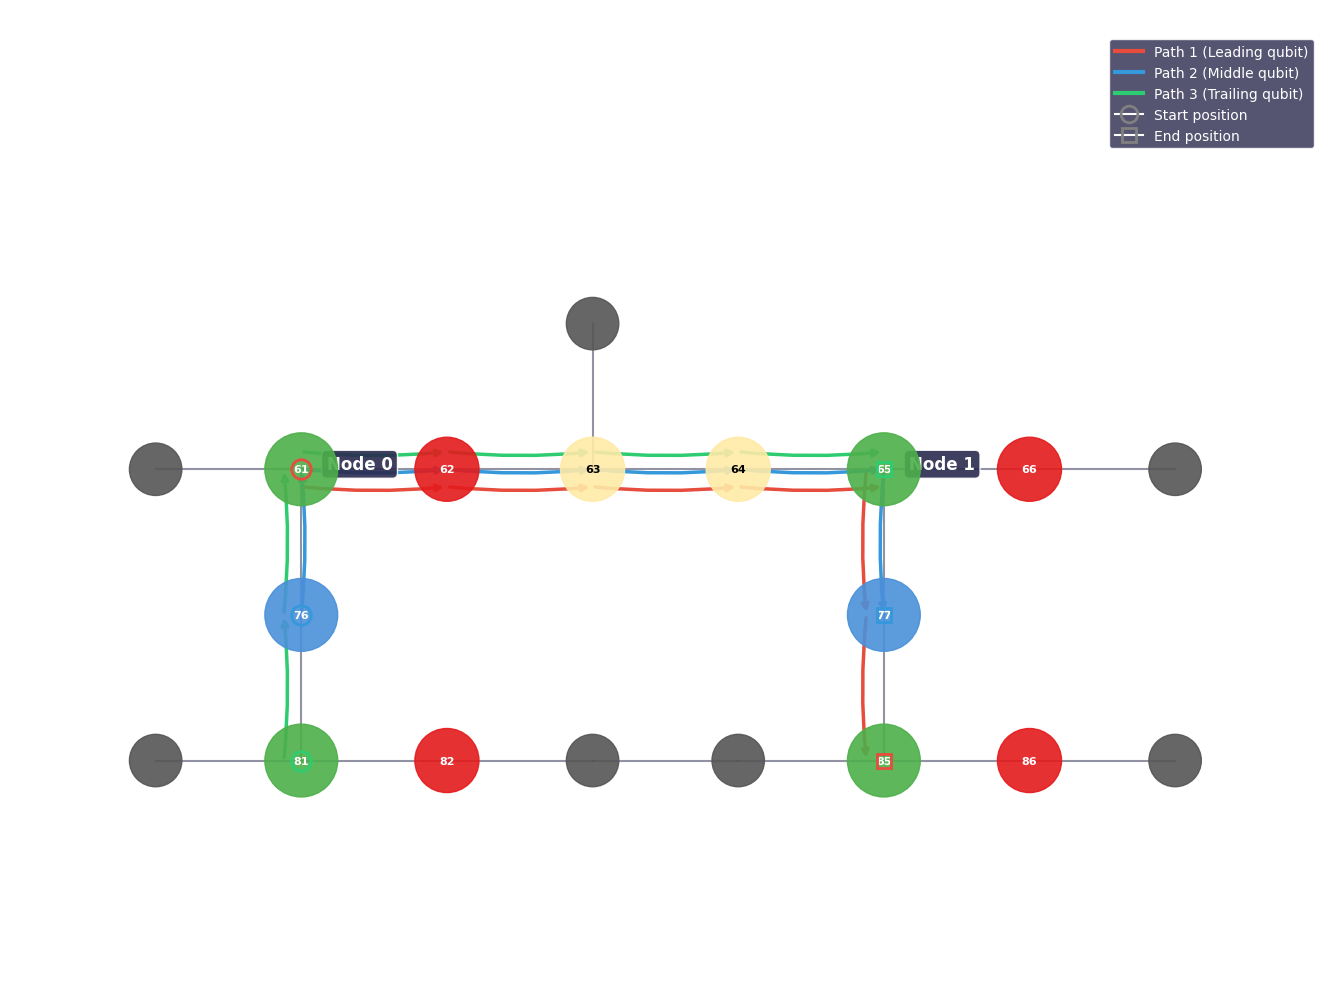


Node 0 --> Node 1 (rightward)
------------------------------------------------------------
Path 1 (Leading): 61 → 85
  Full path: 61 → 62 → 63 → 64 → 65 → 77 → 85
  SWAPs: 6
Path 2 (Middle): 76 → 77
  Full path: 76 → 61 → 62 → 63 → 64 → 65 → 77
  SWAPs: 6
Path 3 (Trailing): 81 → 65
  Full path: 81 → 76 → 61 → 62 → 63 → 64 → 65
  SWAPs: 6


In [12]:
# ============================================================
# VISUALIZE INDIVIDUAL ROUTE WITH STEP-BY-STEP PATH TRACKING
# ============================================================
# Select a route and visualize the sequential qubit movements

def visualize_route_steps(route_key, show_steps=True):
    """
    Create a visualization showing the path for a specific route
    with arrows indicating direction of movement.
    """
    src, dst = route_key
    route = transport_routes[route_key]
    paths = route['movements']
    
    # Collect all qubits involved
    path_qubits = set()
    for path in paths:
        path_qubits.update(path)
    
    # Get source and destination node qubits
    src_node_qubits = set(nodes[src]['data'] + nodes[src]['encoding'] + nodes[src]['ancilla'])
    dst_node_qubits = set(nodes[dst]['data'] + nodes[dst]['encoding'] + nodes[dst]['ancilla'])
    all_relevant = path_qubits | src_node_qubits | dst_node_qubits
    
    # Find neighbors for context
    neighbors = set()
    for q in all_relevant:
        for q1, q2 in coupling_map:
            if q1 == q:
                neighbors.add(q2)
            elif q2 == q:
                neighbors.add(q1)
    
    display_qubits = all_relevant | neighbors
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set_facecolor('#1a1a2e')
    
    # Draw background edges
    for q1, q2 in edges:
        if q1 in display_qubits and q2 in display_qubits and q1 < q2:
            x1, y1 = fez_positions[q1]
            x2, y2 = fez_positions[q2]
            ax.plot([x1, x2], [y1, y2], color='#4a4a6a', linewidth=1.5, zorder=1, alpha=0.6)
    
    # Define colors for each path (qubit)
    path_colors = ['#e74c3c', '#3498db', '#2ecc71']  # Red, Blue, Green
    
    # Draw path edges with arrows
    for path_idx, path in enumerate(paths):
        color = path_colors[path_idx % len(path_colors)]
        
        for step in range(len(path) - 1):
            q1, q2 = path[step], path[step + 1]
            x1, y1 = fez_positions[q1]
            x2, y2 = fez_positions[q2]
            
            # Determine direction of travel
            dx = x2 - x1
            dy = y2 - y1
            is_horizontal = abs(dx) > abs(dy)
            
            # Offset multiplier: red=outside (+1), blue=middle (0), green=inside (-1)
            offset_mult = [1, 0, -1][path_idx]
            base_offset = 0.12
            
            # Calculate offset perpendicular to travel, red on "right side" of direction
            if is_horizontal:
                if dx > 0:  # Moving right -> red below
                    x_off, y_off = 0, -offset_mult * base_offset
                else:  # Moving left -> red above
                    x_off, y_off = 0, offset_mult * base_offset
            else:
                if dy < 0:  # Moving down (screen) -> red left
                    x_off, y_off = -offset_mult * base_offset, 0
                else:  # Moving up (screen) -> red right
                    x_off, y_off = offset_mult * base_offset, 0
            
            # Draw arrow
            ax.annotate('', xy=(x2 + x_off, y2 + y_off), xytext=(x1 + x_off, y1 + y_off),
                       arrowprops=dict(arrowstyle='->', color=color, lw=2.5, 
                                       connectionstyle='arc3,rad=0.05'),
                       zorder=3)
    
    # Draw nodes
    for q in display_qubits:
        if q not in fez_positions:
            continue
        x, y = fez_positions[q]
        
        # Determine color and size (smaller circles)
        if q in nodes[src]['data']:
            color, size = COLOR_DATA, 0.25
        elif q in nodes[src]['encoding']:
            color, size = COLOR_ENCODING, 0.25
        elif q in nodes[src]['ancilla']:
            color, size = COLOR_ANCILLA, 0.22
        elif q in nodes[dst]['data']:
            color, size = COLOR_DATA, 0.25
        elif q in nodes[dst]['encoding']:
            color, size = COLOR_ENCODING, 0.25
        elif q in nodes[dst]['ancilla']:
            color, size = COLOR_ANCILLA, 0.22
        elif q in path_qubits:
            color, size = '#ffeaa7', 0.22
        else:
            color, size = '#555555', 0.18
        
        circle = plt.Circle((x, y), size, color=color, zorder=4, alpha=0.9)
        ax.add_patch(circle)
        
        # Add qubit number
        if q in all_relevant:
            text_color = 'black' if color == '#ffeaa7' else 'white'
            ax.text(x, y, str(q), ha='center', va='center', fontsize=8,
                    color=text_color, fontweight='bold', zorder=5)
    
    # Mark start positions with circles
    for path_idx, path in enumerate(paths):
        x, y = fez_positions[path[0]]
        ax.plot(x, y, 'o', markersize=14, markerfacecolor='none',
                markeredgecolor=path_colors[path_idx], markeredgewidth=2, zorder=6)
    
    # Mark end positions with squares
    for path_idx, path in enumerate(paths):
        x, y = fez_positions[path[-1]]
        ax.plot(x, y, 's', markersize=10, markerfacecolor='none',
                markeredgecolor=path_colors[path_idx], markeredgewidth=2, zorder=6)
    
    # Add node labels
    for n in [src, dst]:
        node_qs = nodes[n]['data'] + nodes[n]['encoding'] + nodes[n]['ancilla']
        cx = np.mean([fez_positions[q][0] for q in node_qs])
        cy = np.mean([fez_positions[q][1] for q in node_qs])
        ax.annotate(f"Node {n}", (cx, cy + 1.0), ha='center', fontsize=12,
                    fontweight='bold', color='white',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a2a4e', 
                              edgecolor='white', alpha=0.9))
    
    # Legend
    legend_elements = [
        plt.Line2D([0], [0], color=path_colors[0], lw=3, label='Path 1 (Leading qubit)'),
        plt.Line2D([0], [0], color=path_colors[1], lw=3, label='Path 2 (Middle qubit)'),
        plt.Line2D([0], [0], color=path_colors[2], lw=3, label='Path 3 (Trailing qubit)'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
                   markeredgecolor='gray', markersize=12, markeredgewidth=2, label='Start position'),
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='none',
                   markeredgecolor='gray', markersize=10, markeredgewidth=2, label='End position'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10,
              facecolor='#2a2a4e', labelcolor='white', edgecolor='white')
    
    # Set limits based on displayed qubits
    x_coords = [fez_positions[q][0] for q in display_qubits if q in fez_positions]
    y_coords = [fez_positions[q][1] for q in display_qubits if q in fez_positions]
    ax.set_xlim(min(x_coords) - 1, max(x_coords) + 1)
    ax.set_ylim(min(y_coords) - 1.5, max(y_coords) + 2)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"Route {src}→{dst}: {route['description']}", 
                 fontsize=14, color='white', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print path details
    print(f"\n{route['description']}")
    print("-" * 60)
    labels = ["Path 1 (Leading)", "Path 2 (Middle)", "Path 3 (Trailing)"]
    for i, path in enumerate(paths):
        print(f"{labels[i]}: {path[0]} → {path[-1]}")
        print(f"  Full path: {' → '.join(map(str, path))}")
        print(f"  SWAPs: {len(path) - 1}")

# Visualize horizontal route (0→1)
print("=" * 70)
print("ROUTE VISUALIZATION: Node 0 → Node 1 (Horizontal)")
print("=" * 70)
visualize_route_steps((0, 1))

Visualizing all 30 routes...


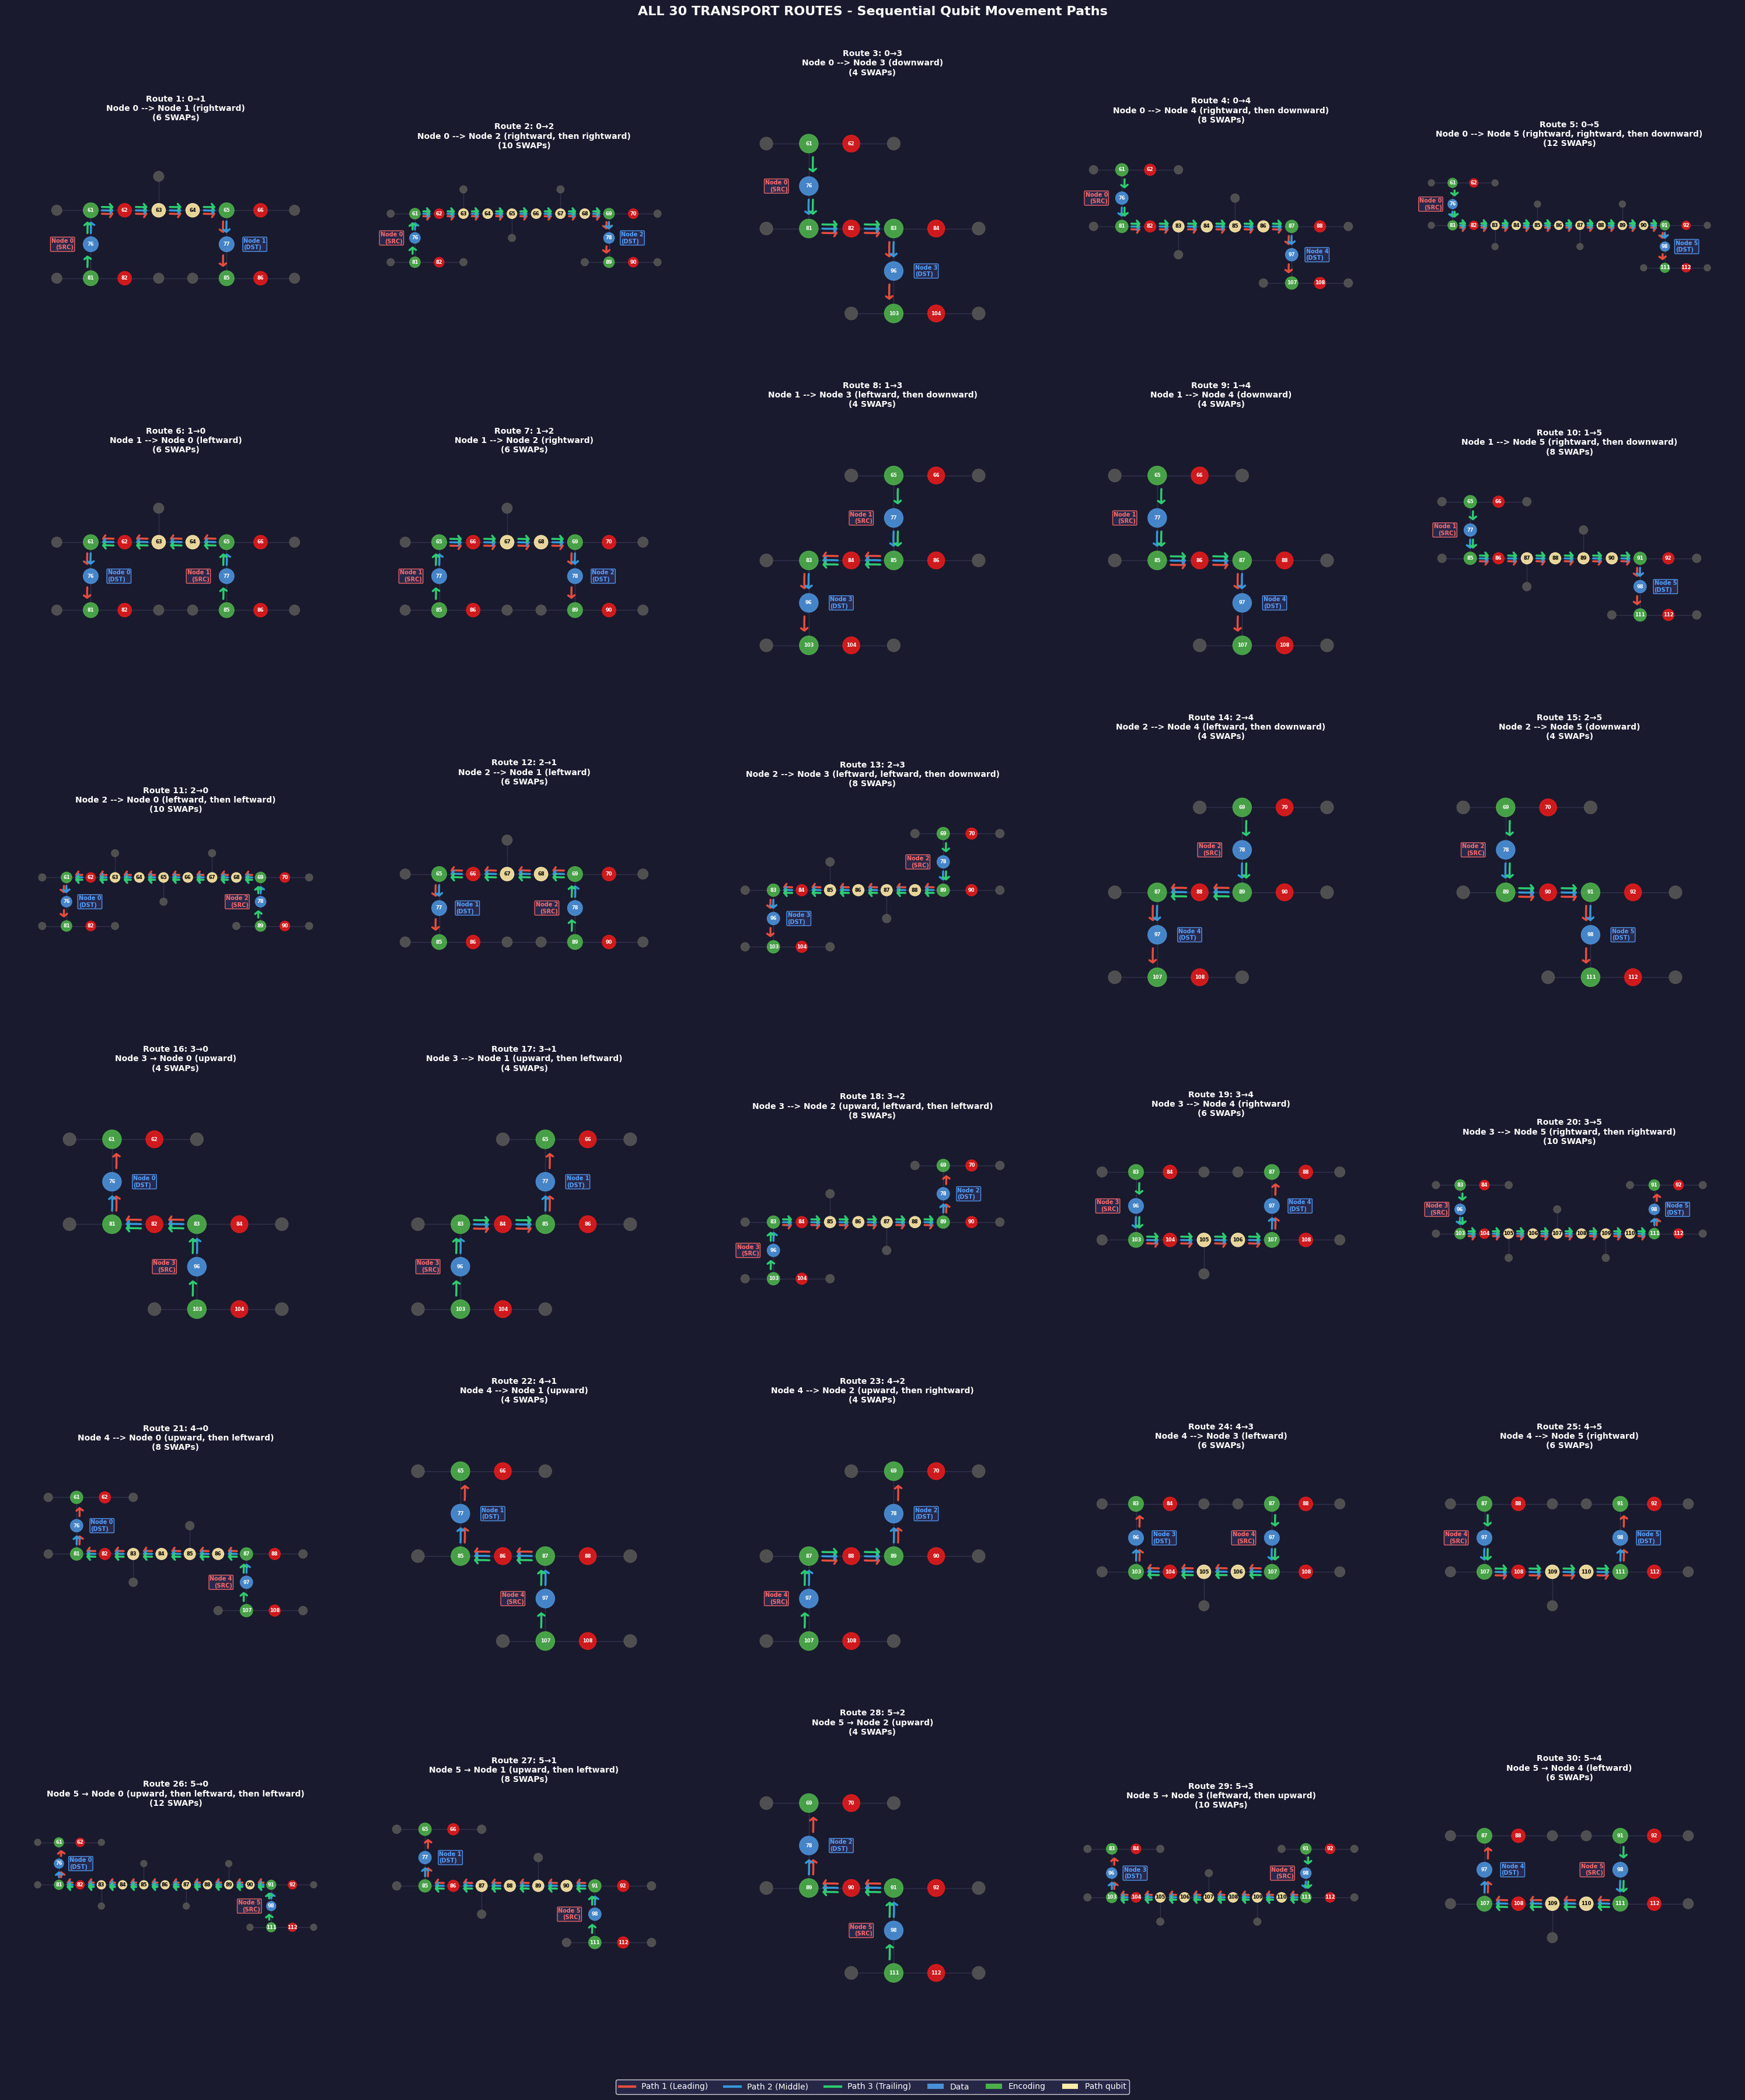


COMPLETE ROUTE SUMMARY - All 30 Routes

Legend:
  - Red arrows (Path 1): Leading qubit - moves first
  - Blue arrows (Path 2): Middle qubit - moves second
  - Green arrows (Path 3): Trailing qubit - moves last

All paths execute SEQUENTIALLY - one completes before the next begins.


In [13]:
# ============================================================
# VISUALIZE ALL 30 ROUTES - EACH IN SEPARATE SUBPLOT
# ============================================================
# Show every route in the transport_routes dictionary

all_routes = list(transport_routes.keys())
num_routes = len(all_routes)
print(f"Visualizing all {num_routes} routes...")

# Create 6x5 grid (30 routes)
fig, axes = plt.subplots(6, 5, figsize=(30, 36))
fig.patch.set_facecolor('#1a1a2e')

path_colors = ['#e74c3c', '#3498db', '#2ecc71']

for idx, route_key in enumerate(all_routes):
    row, col = idx // 5, idx % 5
    ax = axes[row, col]
    ax.set_facecolor('#1a1a2e')
    
    src, dst = route_key
    route = transport_routes[route_key]
    paths = route['movements']
    
    # Collect all qubits
    path_qubits = set()
    for path in paths:
        path_qubits.update(path)
    
    src_node_qubits = set(nodes[src]['data'] + nodes[src]['encoding'] + nodes[src]['ancilla'])
    dst_node_qubits = set(nodes[dst]['data'] + nodes[dst]['encoding'] + nodes[dst]['ancilla'])
    all_relevant = path_qubits | src_node_qubits | dst_node_qubits
    
    neighbors = set()
    for q in all_relevant:
        for q1, q2 in coupling_map:
            if q1 == q:
                neighbors.add(q2)
            elif q2 == q:
                neighbors.add(q1)
    
    display_qubits = all_relevant | neighbors
    
    # Draw background edges
    for q1, q2 in edges:
        if q1 in display_qubits and q2 in display_qubits and q1 < q2:
            x1, y1 = fez_positions[q1]
            x2, y2 = fez_positions[q2]
            ax.plot([x1, x2], [y1, y2], color='#4a4a6a', linewidth=1, zorder=1, alpha=0.5)
    
    # Draw path arrows with bigger arrowheads, shortened to avoid node overlap
    for path_idx, path in enumerate(paths):
        color = path_colors[path_idx % len(path_colors)]
        for step in range(len(path) - 1):
            q1, q2 = path[step], path[step + 1]
            x1, y1 = fez_positions[q1]
            x2, y2 = fez_positions[q2]
            
            # Determine direction of travel
            dx = x2 - x1
            dy = y2 - y1
            is_horizontal = abs(dx) > abs(dy)
            
            # Offset multiplier: red=outside (+1), blue=middle (0), green=inside (-1)
            offset_mult = [1, 0, -1][path_idx]
            base_offset = 0.1
            
            # Calculate offset perpendicular to travel, red on "right side" of direction
            if is_horizontal:
                if dx > 0:  # Moving right -> red below
                    x_off, y_off = 0, -offset_mult * base_offset
                else:  # Moving left -> red above
                    x_off, y_off = 0, offset_mult * base_offset
            else:
                if dy < 0:  # Moving down (screen) -> red left
                    x_off, y_off = -offset_mult * base_offset, 0
                else:  # Moving up (screen) -> red right
                    x_off, y_off = offset_mult * base_offset, 0
            
            # Shorten the arrow to avoid overlapping with nodes
            # Calculate the unit vector and shrink start/end by node radius
            length = np.sqrt(dx**2 + dy**2)
            shrink = 0.28  # Amount to shrink from each end (slightly larger than node radius)
            if length > 0:
                ux, uy = dx / length, dy / length
                # New start and end points, shrunk inward
                new_x1 = x1 + ux * shrink + x_off
                new_y1 = y1 + uy * shrink + y_off
                new_x2 = x2 - ux * shrink + x_off
                new_y2 = y2 - uy * shrink + y_off
            else:
                new_x1, new_y1 = x1 + x_off, y1 + y_off
                new_x2, new_y2 = x2 + x_off, y2 + y_off
            
            # Bigger arrowhead: ->,head_width=0.4,head_length=0.3
            ax.annotate('', xy=(new_x2, new_y2), xytext=(new_x1, new_y1),
                       arrowprops=dict(arrowstyle='->,head_width=0.4,head_length=0.3', 
                                       color=color, lw=2.5,
                                       connectionstyle='arc3,rad=0.03'), zorder=3)
    
    # Draw qubits (smaller sizes)
    for q in display_qubits:
        if q not in fez_positions:
            continue
        x, y = fez_positions[q]
        
        if q in nodes[src]['data'] or q in nodes[dst]['data']:
            color, size = COLOR_DATA, 0.22
        elif q in nodes[src]['encoding'] or q in nodes[dst]['encoding']:
            color, size = COLOR_ENCODING, 0.22
        elif q in nodes[src]['ancilla'] or q in nodes[dst]['ancilla']:
            color, size = COLOR_ANCILLA, 0.2
        elif q in path_qubits:
            color, size = '#ffeaa7', 0.2
        else:
            color, size = '#555555', 0.15
        
        circle = plt.Circle((x, y), size, color=color, zorder=4, alpha=0.9)
        ax.add_patch(circle)
        
        if q in all_relevant:
            text_color = 'black' if color == '#ffeaa7' else 'white'
            ax.text(x, y, str(q), ha='center', va='center', fontsize=6,
                    color=text_color, fontweight='bold', zorder=5)
    
    # Add node labels (Source and Destination) - positioned to left/right of data qubit
    # Get position of source data qubit and place label to the left
    src_data_q = nodes[src]['data'][0]
    src_dx, src_dy = fez_positions[src_data_q]
    ax.annotate(f"Node {src}\n(SRC)", (src_dx - 0.5, src_dy), ha='right', va='center', fontsize=7,
                fontweight='bold', color='#ff6b6b',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='#2a2a4e', 
                          edgecolor='#ff6b6b', alpha=0.9), zorder=10)
    
    # Get position of destination data qubit and place label to the right
    dst_data_q = nodes[dst]['data'][0]
    dst_dx, dst_dy = fez_positions[dst_data_q]
    ax.annotate(f"Node {dst}\n(DST)", (dst_dx + 0.5, dst_dy), ha='left', va='center', fontsize=7,
                fontweight='bold', color='#54a0ff',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='#2a2a4e', 
                          edgecolor='#54a0ff', alpha=0.9), zorder=10)
    
    # Set limits
    x_coords = [fez_positions[q][0] for q in display_qubits if q in fez_positions]
    y_coords = [fez_positions[q][1] for q in display_qubits if q in fez_positions]
    ax.set_xlim(min(x_coords) - 1.5, max(x_coords) + 1.5)
    ax.set_ylim(min(y_coords) - 1.2, max(y_coords) + 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Title with route number
    path_len = len(paths[0]) - 1
    ax.set_title(f"Route {idx+1}: {src}→{dst}\n{route['description']}\n({path_len} SWAPs)",
                 fontsize=10, color='white', fontweight='bold')

# Add overall legend
from matplotlib.patches import Patch
fig.legend(
    handles=[
        plt.Line2D([0], [0], color='#e74c3c', lw=3, label='Path 1 (Leading)'),
        plt.Line2D([0], [0], color='#3498db', lw=3, label='Path 2 (Middle)'),
        plt.Line2D([0], [0], color='#2ecc71', lw=3, label='Path 3 (Trailing)'),
        Patch(facecolor=COLOR_DATA, label='Data'),
        Patch(facecolor=COLOR_ENCODING, label='Encoding'),
        Patch(facecolor='#ffeaa7', label='Path qubit'),
    ],
    loc='upper center', ncol=6, fontsize=10,
    facecolor='#2a2a4e', labelcolor='white', edgecolor='white',
    bbox_to_anchor=(0.5, 0.01)
)

plt.suptitle('ALL 30 TRANSPORT ROUTES - Sequential Qubit Movement Paths',
             fontsize=16, color='white', fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()

print(f"\n{'='*70}")
print(f"COMPLETE ROUTE SUMMARY - All {num_routes} Routes")
print(f"{'='*70}")
print("\nLegend:")
print("  - Red arrows (Path 1): Leading qubit - moves first")
print("  - Blue arrows (Path 2): Middle qubit - moves second")
print("  - Green arrows (Path 3): Trailing qubit - moves last")
print("\nAll paths execute SEQUENTIALLY - one completes before the next begins.")

In [14]:
import os
import json

# Create configs directory if it doesn't exist
CONFIG_DIR = '../configs'
os.makedirs(CONFIG_DIR, exist_ok=True)

# Save nodes dict
with open(f'{CONFIG_DIR}/config_1_nodes.json', 'w') as f:
    json.dump(nodes, f, indent=2)

# Save transport routes dict
with open(f'{CONFIG_DIR}/config_1_routes.json', 'w') as f:
    json.dump({f"{k[0]},{k[1]}": v for k, v in transport_routes.items()}, f, indent=2)

print(f"Saved {CONFIG_DIR}/config_1_nodes.json")
print(f"Saved {CONFIG_DIR}/config_1_routes.json")

Saved ../configs/config_1_nodes.json
Saved ../configs/config_1_routes.json
